# 07 - XAI Dashboard

**Project:** Early Disease Risk Predictor
**Phase:** 5 - Explainability

---

This notebook builds an explainable AI dashboard using SHAP (SHapley Additive exPlanations) to interpret XGBoost predictions for all three diseases.

| Section | Content |
|---|---|
| 1 | Load data and recreate test splits |
| 2 | Load trained models |
| 3 | SHAP explainers and value computation |
| 4 | Global feature importance - bar charts |
| 5 | Global feature importance - beeswarm plots |
| 6 | Local waterfall explanations |
| 7 | Force plots for individual predictions |
| 8 | Decision plots - cumulative contribution paths |
| 9 | SHAP dependence plots - feature interactions |
| 10 | Cross-disease feature importance comparison |
| 11 | Patient prediction interface |
| 12 | Per-model SHAP comparison (XGBoost vs Random Forest) |
| 13 | XAI insights summary |

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import xgboost as xgb

from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROC_DIR   = os.path.join('..', 'data', 'processed')
MODEL_DIR  = os.path.join('..', 'data', 'models')
FIGS_DIR   = os.path.join('..', 'reports', 'figures')

DISEASES      = ['diabetes', 'heart_disease', 'hypertension']
DIS_LABEL     = {'diabetes': 'Diabetes',
                 'heart_disease': 'Heart Disease',
                 'hypertension': 'Hypertension'}
FEATURE_NAMES = ['age', 'bmi', 'glucose', 'blood_pressure',
                 'insulin', 'cholesterol', 'source_pima', 'source_uci_heart']
FEAT_DISPLAY  = ['Age', 'BMI (log)', 'Glucose (log)', 'Blood Pressure',
                 'Insulin', 'Cholesterol', 'Src: PIMA', 'Src: UCI Heart']
LOG_FEATS     = ['bmi', 'glucose']   # log1p-transformed in notebook 04
SCALE_FEATS   = ['age', 'bmi', 'glucose', 'blood_pressure', 'insulin', 'cholesterol']
RANDOM_STATE  = 42
DIS_COLORS    = {'diabetes': '#E85D5D',
                 'heart_disease': '#4C9BE8',
                 'hypertension': '#FFA040'}

# Map feature name → column index (used in dependence plots)
FEAT_IDX = {f: i for i, f in enumerate(FEATURE_NAMES)}

print('Setup complete.')

Setup complete.


### XGBoost SHAP Helper

SHAP 0.47 cannot parse the base_score format introduced in XGBoost 3.0.
We bypass this by using XGBoost's own `pred_contribs=True` API, which computes
exact Shapley values natively and returns them as a (n_samples, n_features + 1)
matrix - the last column is the per-sample bias (constant, equals the log-odds
base score). We then wrap the result in a `shap.Explanation` object so all
standard SHAP plotting functions work normally.

In [2]:
def xgb_shap(model, X_df, feat_names=None):
    """
    Compute exact SHAP values using XGBoost's native pred_contribs.
    Returns a shap.Explanation compatible with all shap.plots.* functions.
    """
    booster  = model.get_booster()
    cols     = list(X_df.columns)
    dmat     = xgb.DMatrix(X_df, feature_names=cols)
    contribs = booster.predict(dmat, pred_contribs=True)   # (n, n_feats+1)
    sv_vals  = contribs[:, :-1]   # SHAP contributions per feature
    bias_vec = contribs[:, -1]    # bias / base value (constant across rows)
    return shap.Explanation(
        values        = sv_vals,
        base_values   = bias_vec,
        data          = X_df.values,
        feature_names = feat_names if feat_names else cols
    )


print('xgb_shap() helper ready.')

xgb_shap() helper ready.


## 1. Load Data and Recreate Test Splits

The identical 70 / 15 / 15 stratified split from notebook 06 is reconstructed using `random_state=42`, giving the exact same held-out test rows.

In [3]:
datasets = {}
for disease in DISEASES:
    X = pd.read_csv(os.path.join(PROC_DIR, f'X_{disease}.csv'))
    y = pd.read_csv(os.path.join(PROC_DIR, f'y_{disease}.csv')).squeeze()
    datasets[disease] = (X, y)
    print(f'{disease:15s} | X{X.shape}  pos_rate={y.mean():.3f}')

std_scaler = joblib.load(os.path.join(PROC_DIR, 'standard_scaler.pkl'))
print(f'\nScaler loaded | features: {list(std_scaler.feature_names_in_)}')

diabetes        | X(5311, 8)  pos_rate=0.050
heart_disease   | X(5311, 8)  pos_rate=0.147
hypertension    | X(5311, 8)  pos_rate=0.379

Scaler loaded | features: ['age', 'bmi', 'glucose', 'blood_pressure', 'insulin', 'cholesterol']


In [4]:
splits = {}
for disease, (X, y) in datasets.items():
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )
    X_va, X_te, y_va, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_tmp
    )
    splits[disease] = (X_tr, X_va, X_te, y_tr, y_va, y_te)
    print(f'{disease:15s} | test n={len(X_te):4d}  pos_rate={y_te.mean():.3f}')

print('\nTest splits reconstructed (identical to notebook 06).')

diabetes        | test n= 797  pos_rate=0.050
heart_disease   | test n= 797  pos_rate=0.147
hypertension    | test n= 797  pos_rate=0.379

Test splits reconstructed (identical to notebook 06).


## 2. Load Trained Models

In [5]:
xgb_models = {}
rf_models  = {}
lr_models  = {}

for disease in DISEASES:
    xgb_models[disease] = joblib.load(os.path.join(MODEL_DIR, f'xgb_{disease}.pkl'))
    rf_models[disease]  = joblib.load(os.path.join(MODEL_DIR, f'rf_{disease}.pkl'))
    lr_models[disease]  = joblib.load(os.path.join(MODEL_DIR, f'lr_{disease}.pkl'))

print('Loaded: XGBoost, Random Forest, Logistic Regression - 3 diseases each.')
print('Primary explainability model: XGBoost (native pred_contribs - exact Shapley)')

Loaded: XGBoost, Random Forest, Logistic Regression - 3 diseases each.
Primary explainability model: XGBoost (native pred_contribs - exact Shapley)


## 3. SHAP Value Computation

**XGBoost** - `pred_contribs=True` computes exact Shapley values by traversing the decision trees. Values are in log-odds space (before sigmoid activation).

**Random Forest** - `shap.TreeExplainer` (sklearn RF is fully supported in SHAP 0.47).

In [6]:
shap_values_xgb = {}
shap_values_rf  = {}

explainers_rf   = {}   # kept for base_value access

print('Computing SHAP values...\n')
for disease in DISEASES:
    X_te = splits[disease][2]

    # XGBoost - native Shapley (bypasses SHAP-XGBoost version incompatibility)
    sv_xgb = xgb_shap(xgb_models[disease], X_te, feat_names=FEAT_DISPLAY)
    shap_values_xgb[disease] = sv_xgb

    # Random Forest - shap.TreeExplainer (exact, sklearn-compatible)
    # Binary RF returns 3D SHAP values (n, n_features, 2); take class-1 slice.
    exp_rf  = shap.TreeExplainer(rf_models[disease])
    sv_rf   = exp_rf(X_te)
    rf_vals = sv_rf.values
    rf_bv   = sv_rf.base_values
    if rf_vals.ndim == 3:
        rf_vals = rf_vals[:, :, 1]
    if np.ndim(rf_bv) > 1:
        rf_bv = rf_bv[:, 1]
    sv_rf_named = shap.Explanation(
        values        = rf_vals,
        base_values   = rf_bv,
        data          = sv_rf.data,
        feature_names = FEAT_DISPLAY
    )
    explainers_rf[disease]  = exp_rf
    shap_values_rf[disease] = sv_rf_named

    base_xgb = float(sv_xgb.base_values[0])
    base_rf  = float(np.atleast_1d(exp_rf.expected_value)[0])
    print(f'[{DIS_LABEL[disease]:15s}]  '
          f'XGB base={base_xgb:.4f}  |  RF base={base_rf:.4f}  |  test_n={len(X_te)}')

print('\nSHAP computation complete.')

Computing SHAP values...



[Diabetes       ]  XGB base=0.0678  |  RF base=0.5007  |  test_n=797


[Heart Disease  ]  XGB base=0.0398  |  RF base=0.5010  |  test_n=797


[Hypertension   ]  XGB base=-0.0704  |  RF base=0.4994  |  test_n=797

SHAP computation complete.


## 4. Global Feature Importance - Mean |SHAP|

Mean absolute SHAP value across all test samples gives a model-consistent global importance score. Unlike impurity-based importance (which favours high-cardinality features), SHAP importance directly measures each feature's average contribution to predictions.

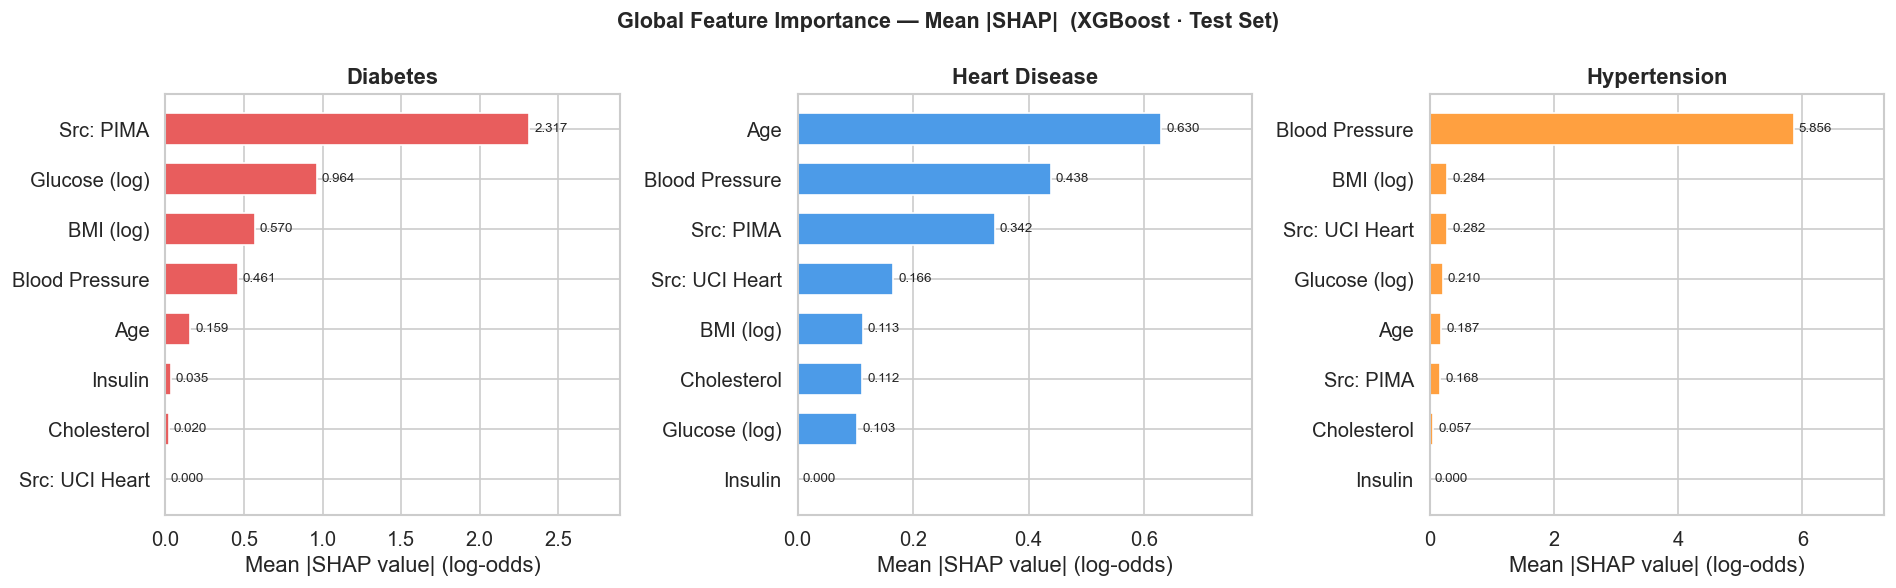


Diabetes
       Feature  Mean |SHAP|
     Src: PIMA       2.3170
 Glucose (log)       0.9640
     BMI (log)       0.5697
Blood Pressure       0.4609
           Age       0.1589
       Insulin       0.0351
   Cholesterol       0.0197
Src: UCI Heart       0.0000

Heart Disease
       Feature  Mean |SHAP|
           Age       0.6299
Blood Pressure       0.4380
     Src: PIMA       0.3416
Src: UCI Heart       0.1658
     BMI (log)       0.1126
   Cholesterol       0.1118
 Glucose (log)       0.1033
       Insulin       0.0000

Hypertension
       Feature  Mean |SHAP|
Blood Pressure       5.8561
     BMI (log)       0.2838
Src: UCI Heart       0.2817
 Glucose (log)       0.2096
           Age       0.1867
     Src: PIMA       0.1682
   Cholesterol       0.0571
       Insulin       0.0000


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, disease in zip(axes, DISEASES):
    sv            = shap_values_xgb[disease]
    mean_abs_shap = np.abs(sv.values).mean(axis=0)
    order         = np.argsort(mean_abs_shap)

    bars = ax.barh(
        [FEAT_DISPLAY[i] for i in order],
        mean_abs_shap[order],
        color=DIS_COLORS[disease], edgecolor='white', height=0.65
    )
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    ax.set_title(DIS_LABEL[disease], fontweight='bold')
    ax.set_xlabel('Mean |SHAP value| (log-odds)')
    ax.set_xlim(0, mean_abs_shap.max() * 1.25)

plt.suptitle('Global Feature Importance - Mean |SHAP|  (XGBoost · Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '24_shap_bar_importance.png'))
plt.show()

# Ranked tables
for disease in DISEASES:
    sv            = shap_values_xgb[disease]
    mean_abs_shap = np.abs(sv.values).mean(axis=0)
    df_imp = pd.DataFrame({
        'Feature'    : FEAT_DISPLAY,
        'Mean |SHAP|': mean_abs_shap.round(4)
    }).sort_values('Mean |SHAP|', ascending=False)
    print(f'\n{DIS_LABEL[disease]}')
    print(df_imp.to_string(index=False))

## 5. Global Feature Importance - Beeswarm Plots

Beeswarm plots show both the **magnitude** and **direction** of each feature's effect. Each dot represents one test sample:

- **Position (x-axis)** - SHAP value: positive pushes the prediction toward disease, negative away from it
- **Color** - feature value: red = high, blue = low

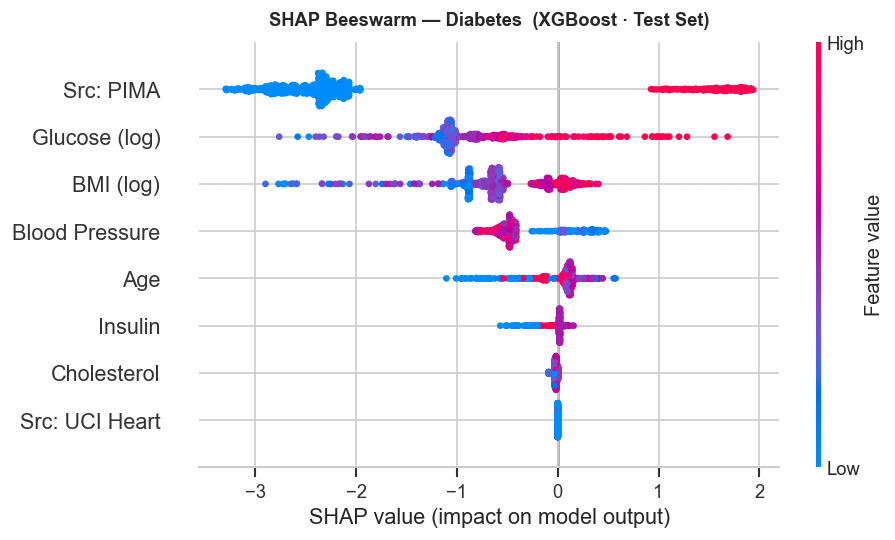

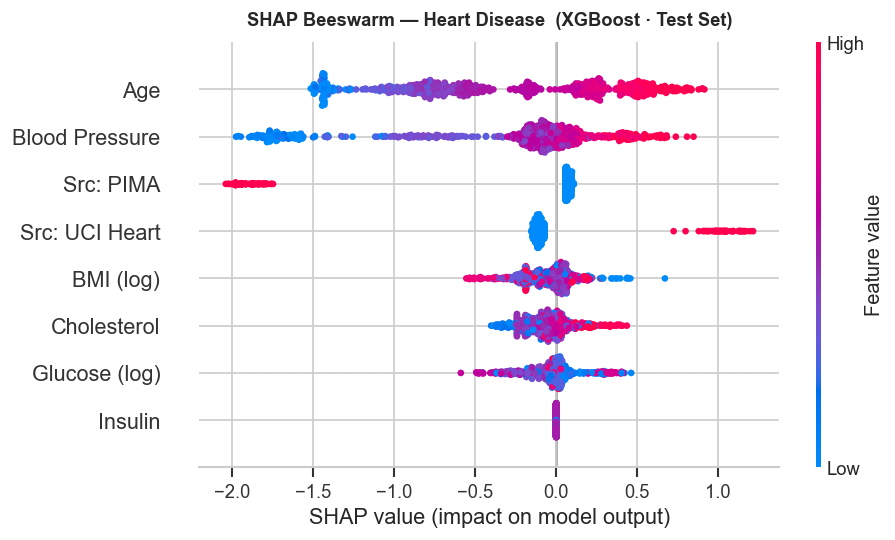

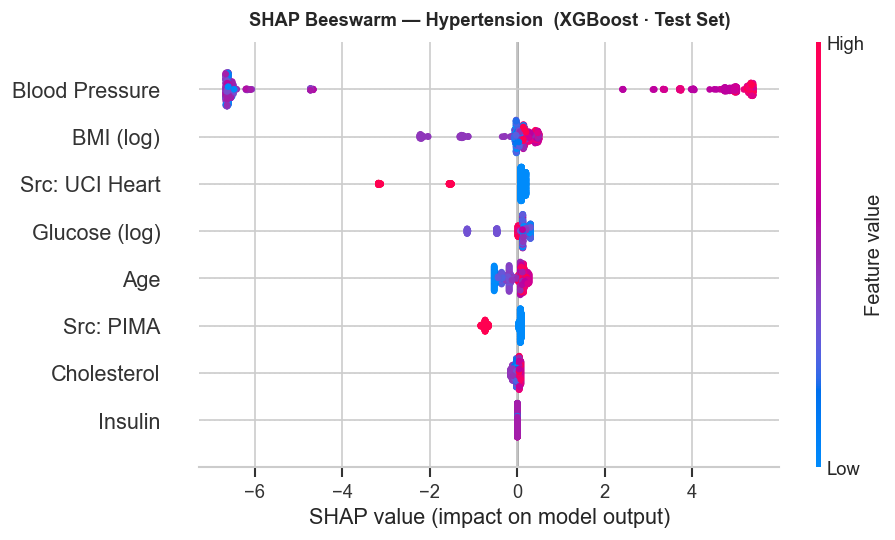

In [8]:
for disease in DISEASES:
    shap.plots.beeswarm(shap_values_xgb[disease], show=False, max_display=8)
    plt.title(f'SHAP Beeswarm - {DIS_LABEL[disease]}  (XGBoost · Test Set)',
              fontsize=11, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR, f'25_shap_beeswarm_{disease}.png'),
                bbox_inches='tight')
    plt.show()

## 6. Local Waterfall Explanations

Waterfall plots explain **individual predictions** by showing how each feature pushes the model output up (red) or down (blue) from the base value to the final prediction.

Four representative cases per disease:

| Case | Description |
|---|---|
| **TP** | True Positive - high-risk patient correctly identified |
| **FN** | False Negative - positive patient the model missed |
| **FP** | False Positive - healthy patient incorrectly flagged |
| **TN** | True Negative - low-risk patient correctly cleared |

In [9]:
case_indices = {}

for disease in DISEASES:
    X_te   = splits[disease][2]
    y_te   = splits[disease][5].values
    clf    = xgb_models[disease]
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]

    tp_idx = np.where((y_te == 1) & (y_pred == 1))[0]
    fn_idx = np.where((y_te == 1) & (y_pred == 0))[0]
    fp_idx = np.where((y_te == 0) & (y_pred == 1))[0]
    tn_idx = np.where((y_te == 0) & (y_pred == 0))[0]

    cases = {}
    if len(tp_idx): cases['TP'] = tp_idx[np.argmax(y_prob[tp_idx])]
    if len(fn_idx): cases['FN'] = fn_idx[np.argmax(y_prob[fn_idx])]
    if len(fp_idx): cases['FP'] = fp_idx[np.argmax(y_prob[fp_idx])]
    if len(tn_idx): cases['TN'] = tn_idx[np.argmin(y_prob[tn_idx])]

    case_indices[disease] = cases
    print(f'\n{DIS_LABEL[disease]}')
    for k, v in cases.items():
        print(f'  {k}: row={v}  p={y_prob[v]:.3f}  true={y_te[v]}')


Diabetes
  TP: row=210  p=0.975  true=1
  FN: row=588  p=0.407  true=1
  FP: row=491  p=0.977  true=0
  TN: row=746  p=0.013  true=0

Heart Disease
  TP: row=499  p=0.885  true=1
  FN: row=452  p=0.500  true=1
  FP: row=595  p=0.915  true=0
  TN: row=713  p=0.003  true=0

Hypertension
  TP: row=229  p=0.999  true=1
  TN: row=308  p=0.000  true=0



=== Diabetes ===


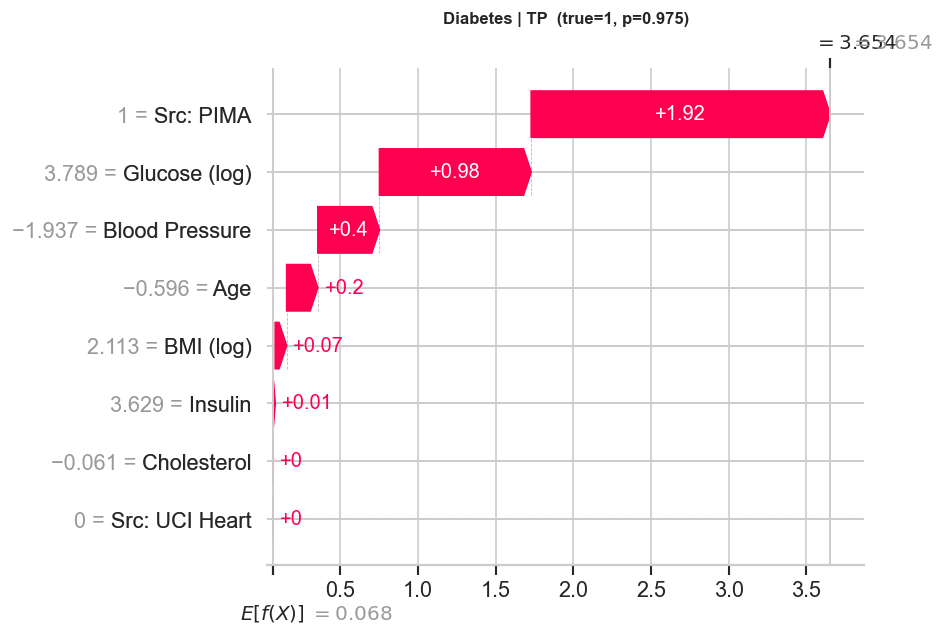

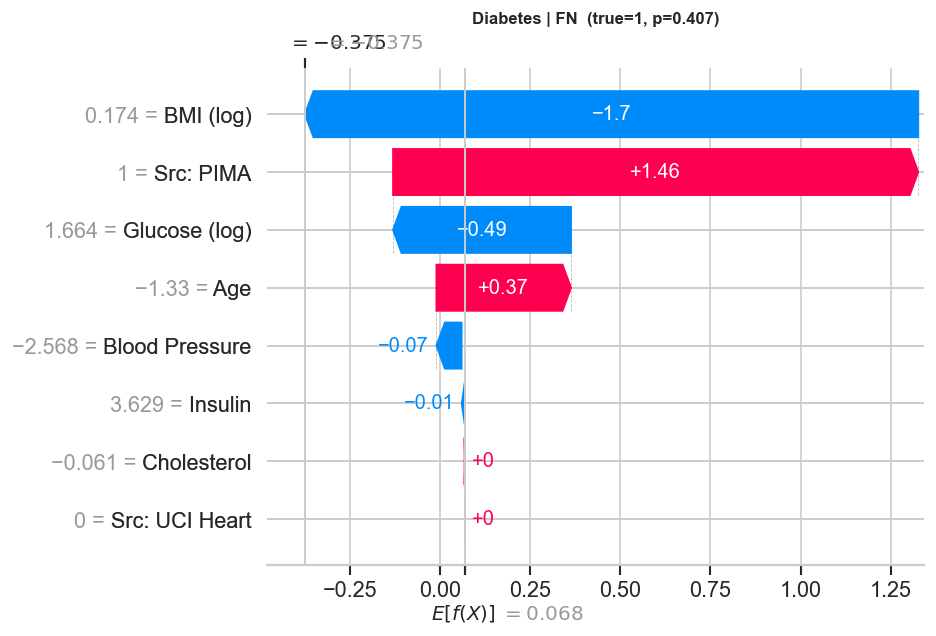

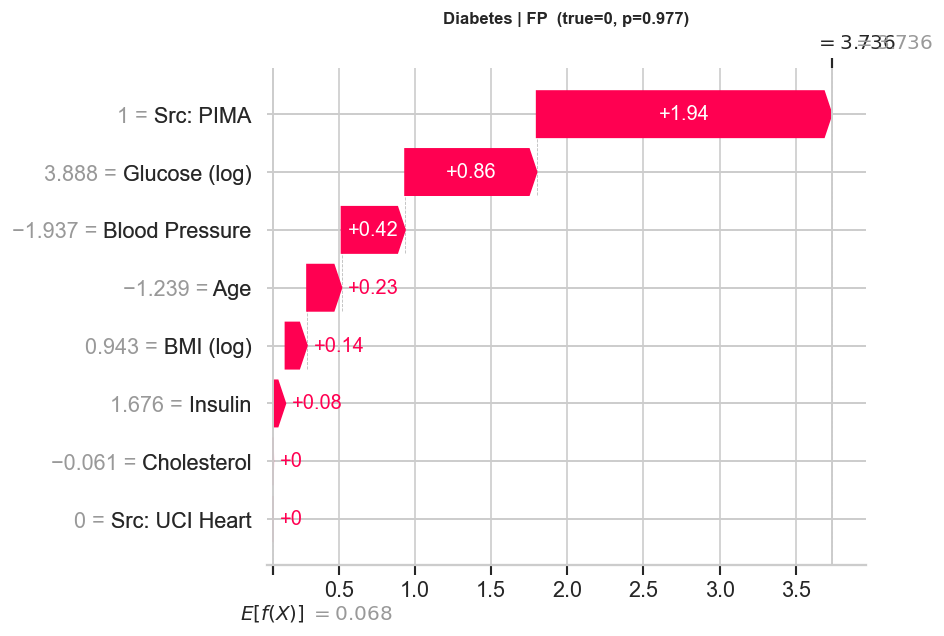

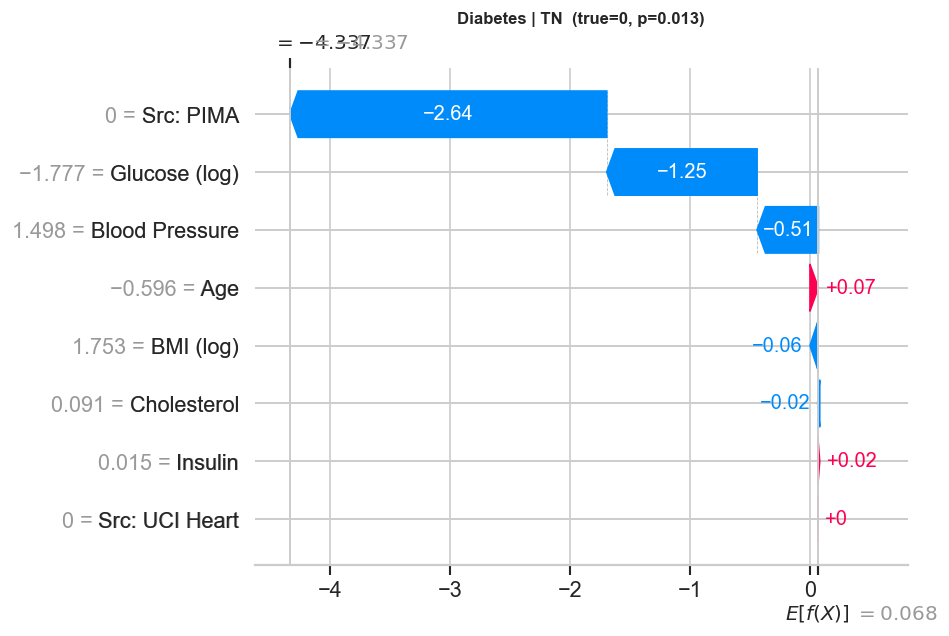


=== Heart Disease ===


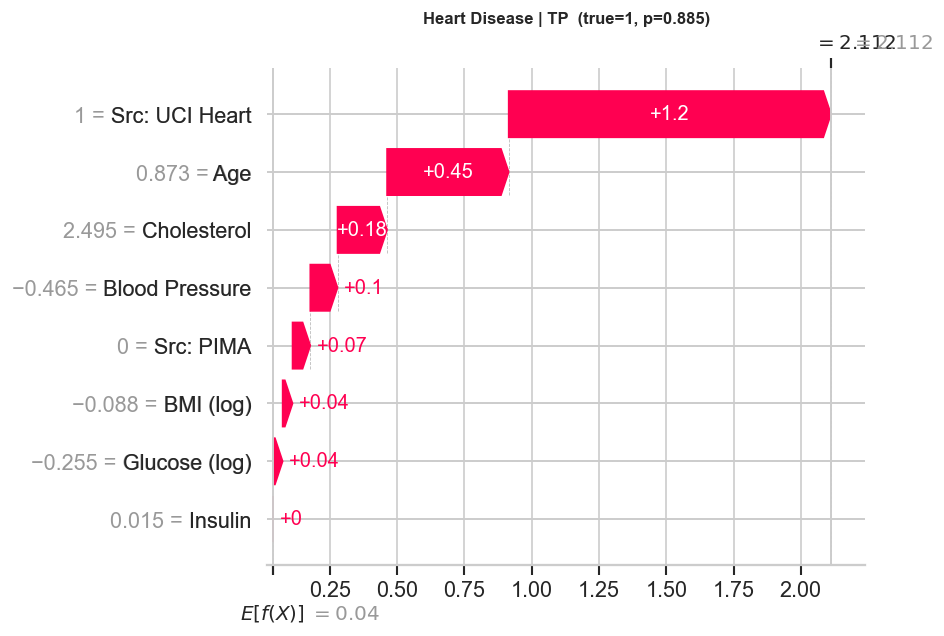

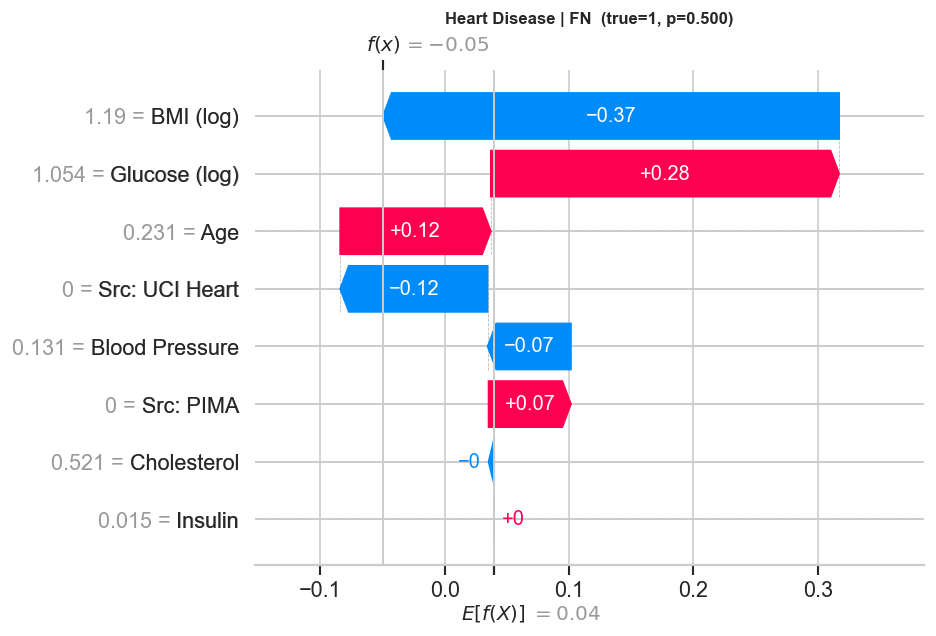

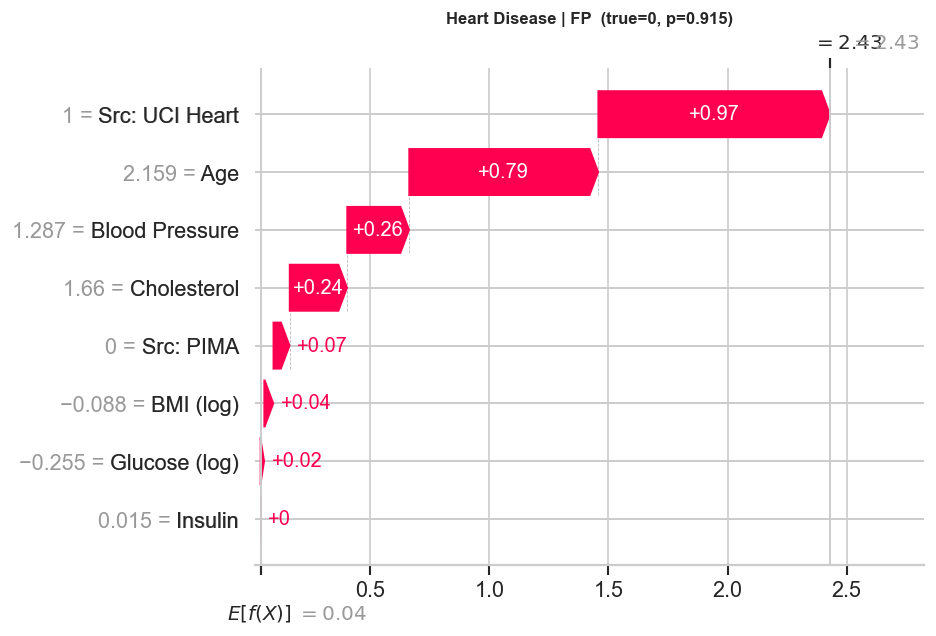

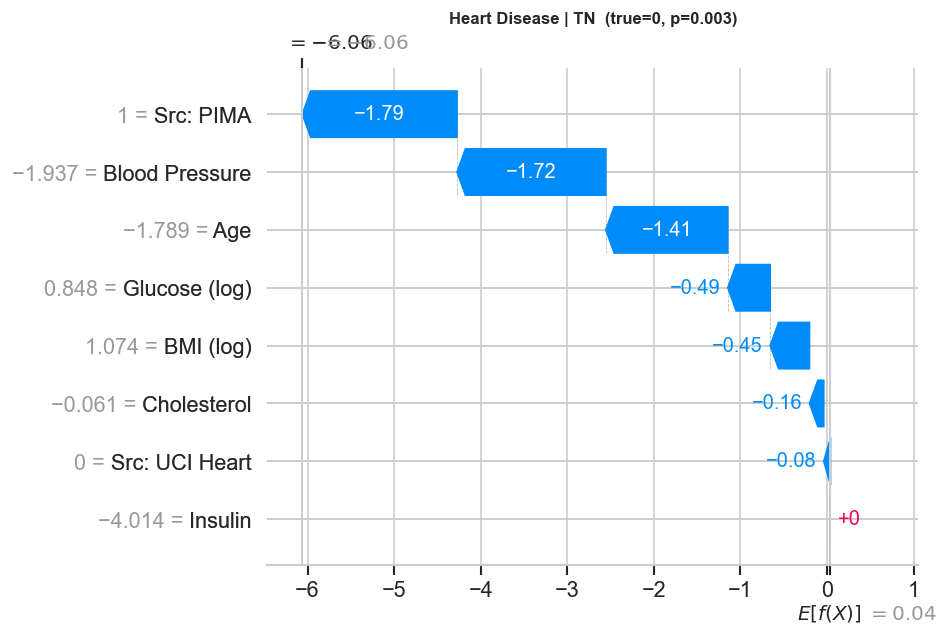


=== Hypertension ===


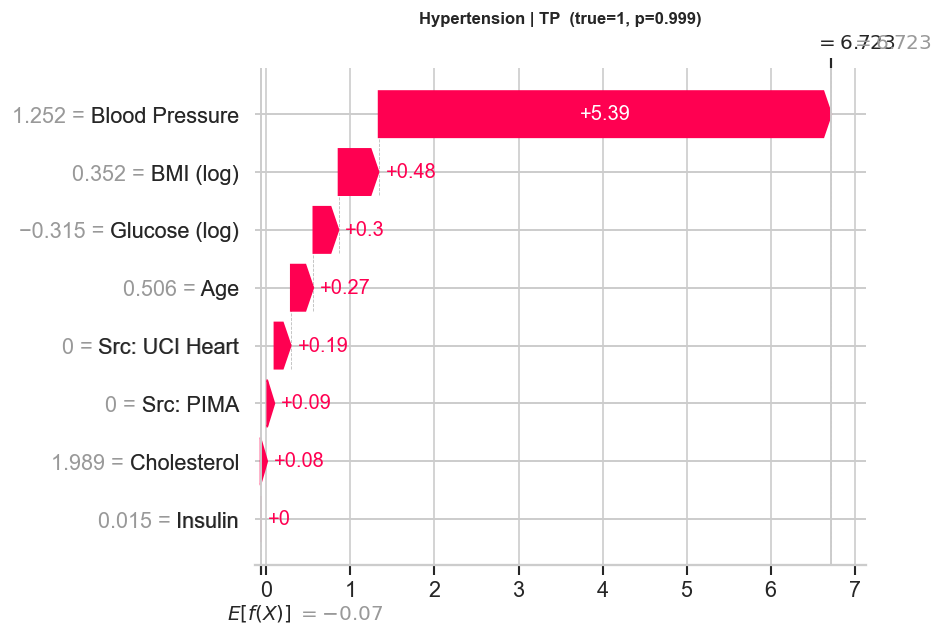

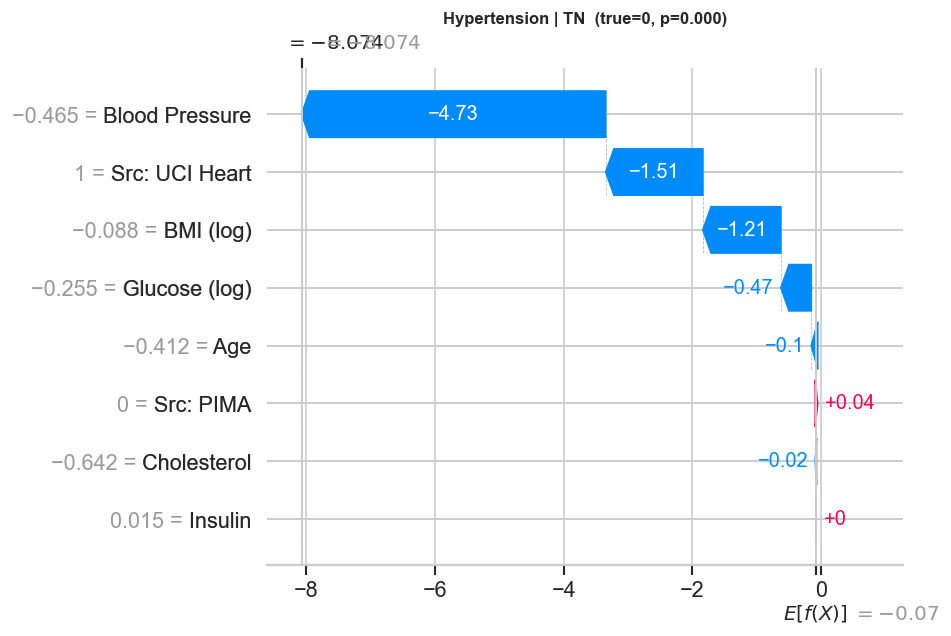

In [10]:
for disease in DISEASES:
    sv     = shap_values_xgb[disease]
    y_te   = splits[disease][5].values
    y_prob = xgb_models[disease].predict_proba(splits[disease][2])[:, 1]
    cases  = case_indices[disease]

    print(f'\n=== {DIS_LABEL[disease]} ===')
    for case_label, idx in cases.items():
        sv_single = shap.Explanation(
            values        = sv.values[idx],
            base_values   = float(sv.base_values[idx]),
            data          = sv.data[idx],
            feature_names = FEAT_DISPLAY
        )
        shap.plots.waterfall(sv_single, show=False, max_display=8)
        plt.title(
            f'{DIS_LABEL[disease]} | {case_label}  '
            f'(true={int(y_te[idx])}, p={y_prob[idx]:.3f})',
            fontsize=10, fontweight='bold'
        )
        plt.tight_layout()
        plt.savefig(os.path.join(FIGS_DIR,
                    f'26_waterfall_{disease}_{case_label}.png'), bbox_inches='tight')
        plt.show()

## 7. Force Plots - Feature Contribution Ribbons

Force plots show the same local explanation as waterfall plots but as a horizontal ribbon. Red segments push the prediction higher; blue segments pull it lower. The width reflects the magnitude of each SHAP value.

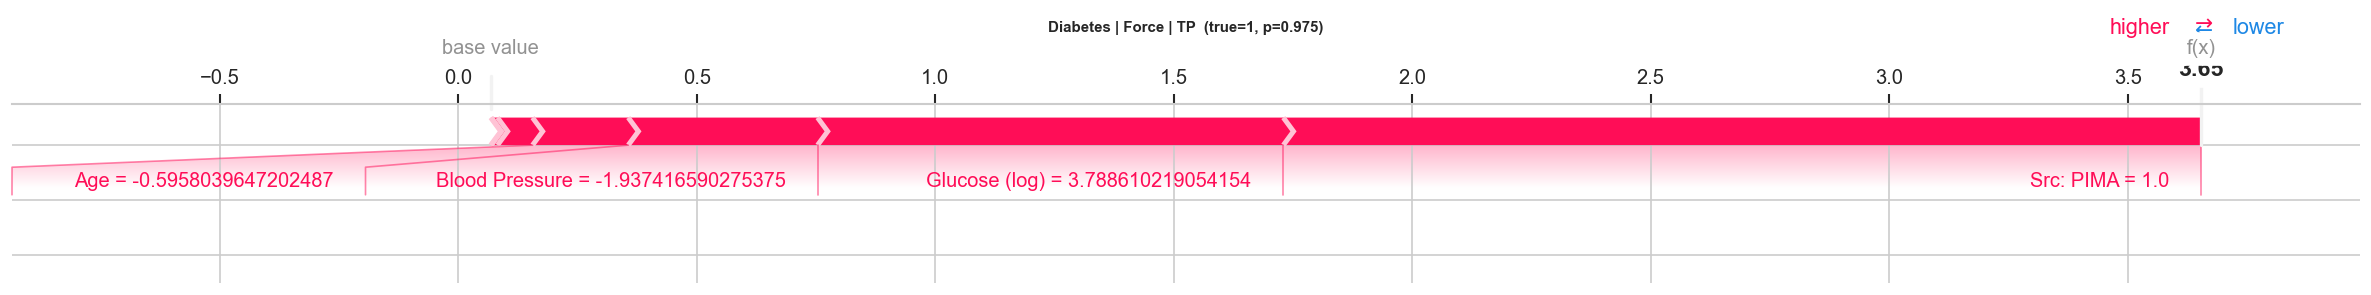

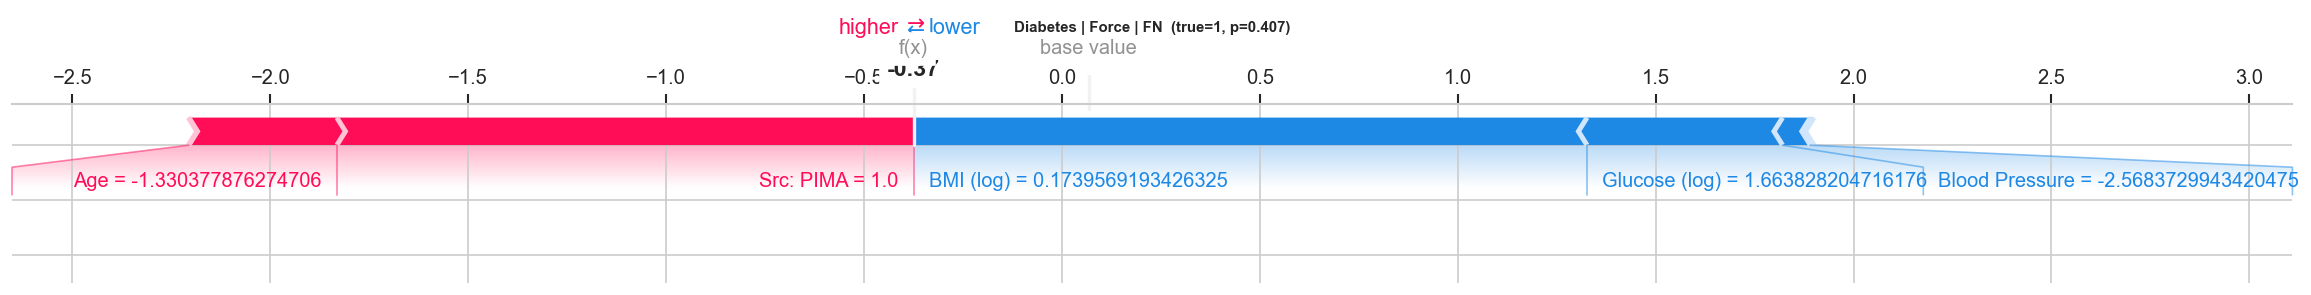

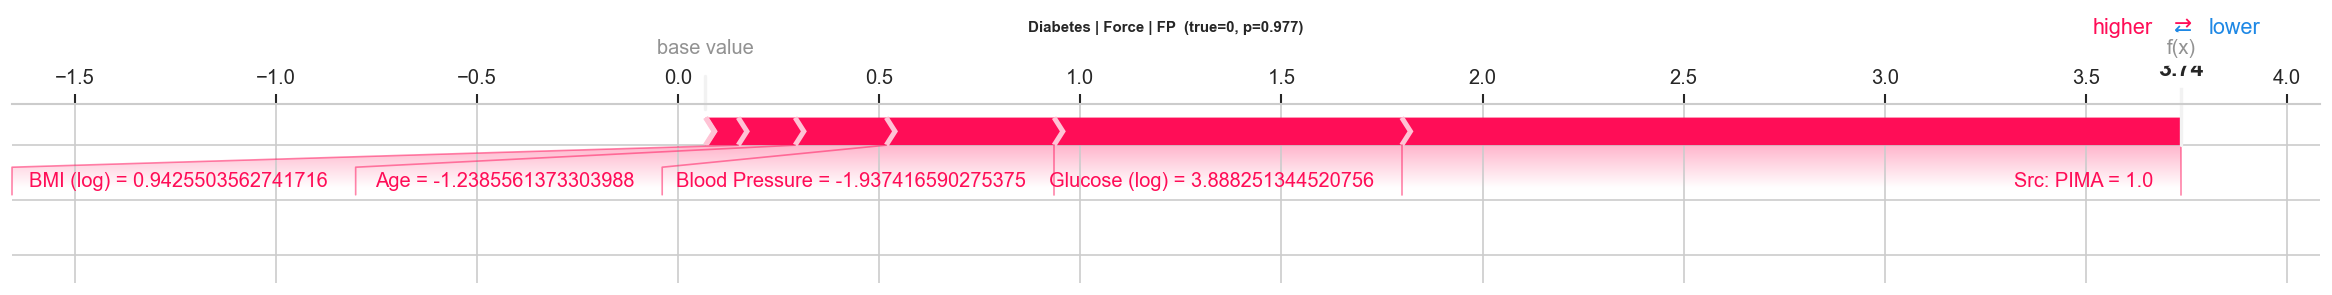

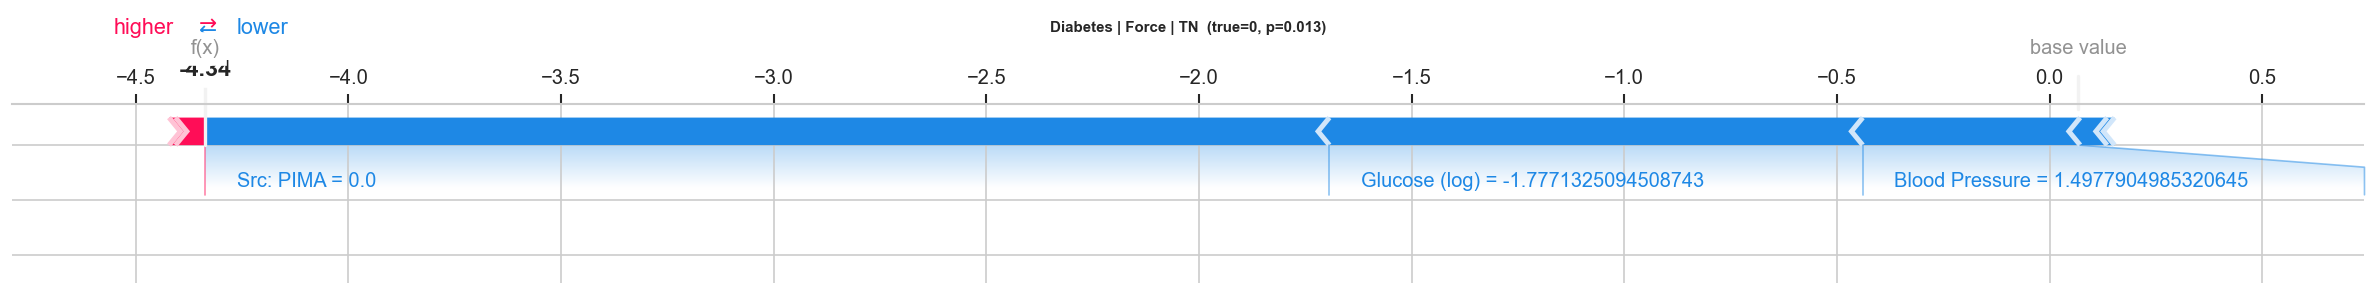

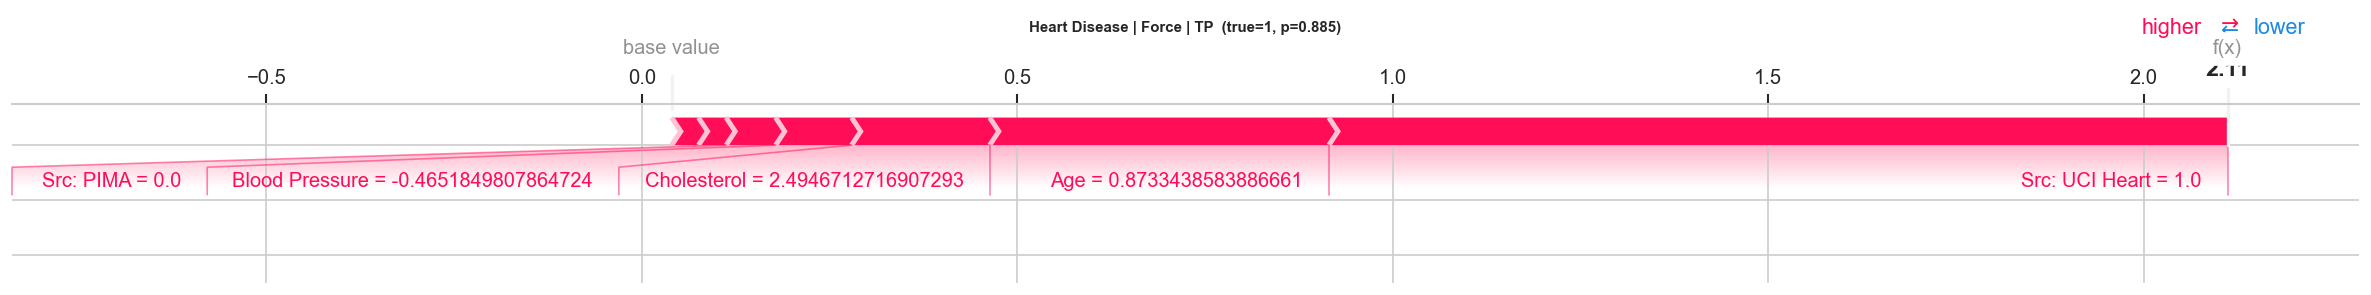

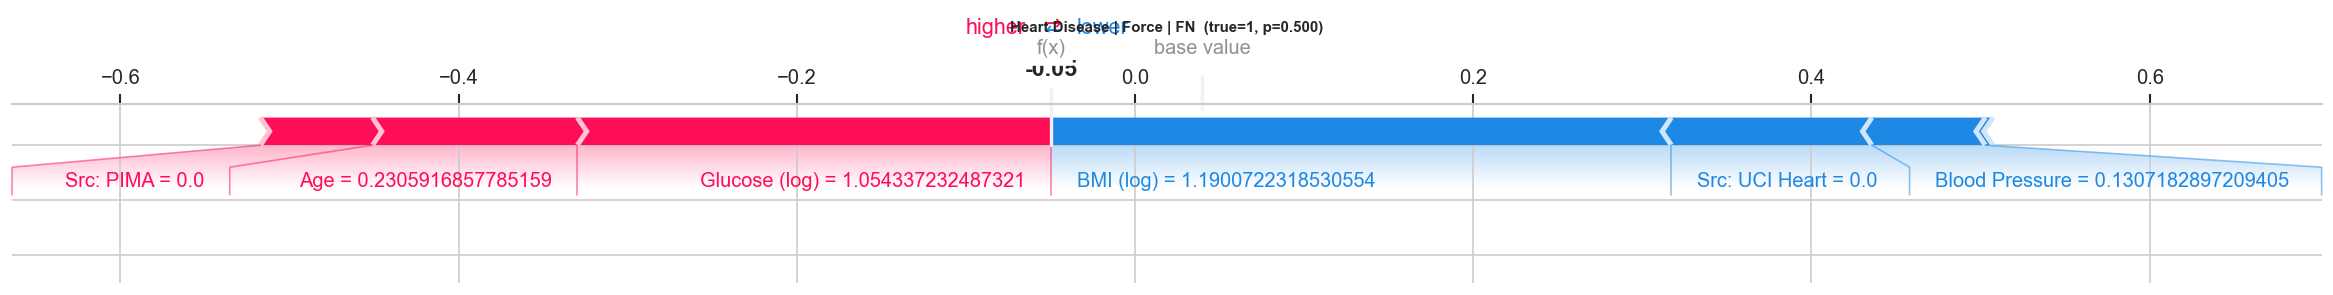

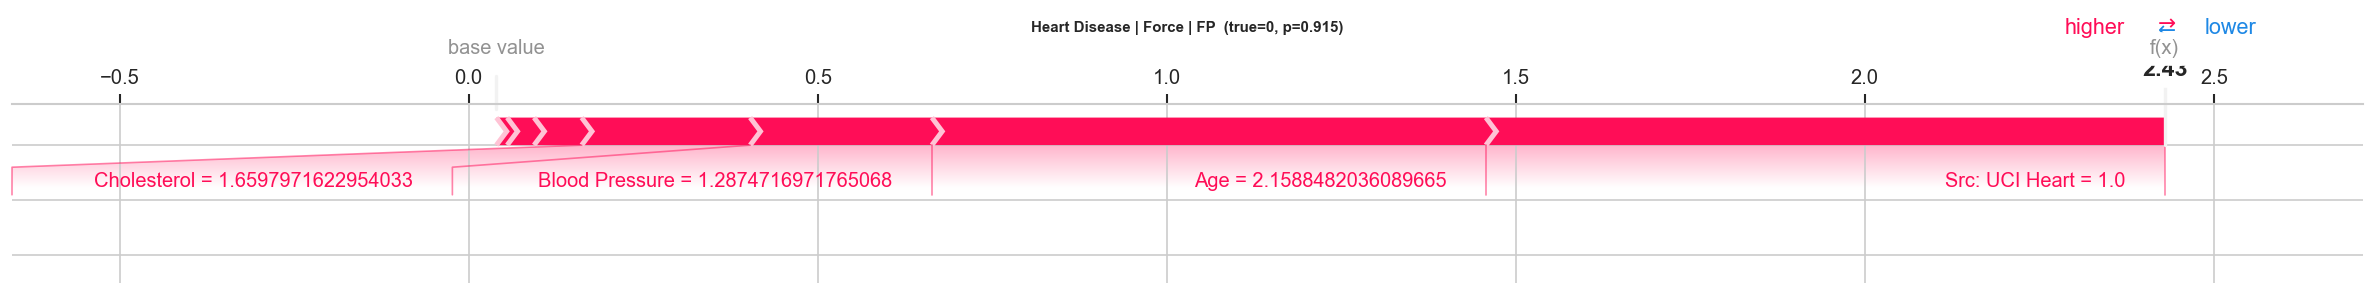

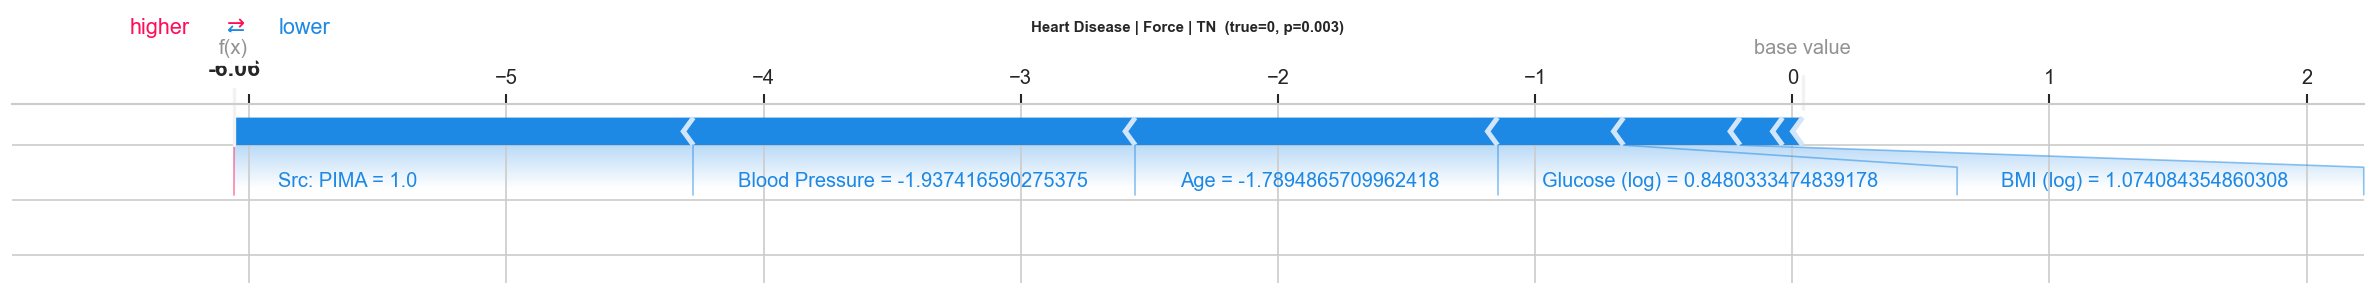

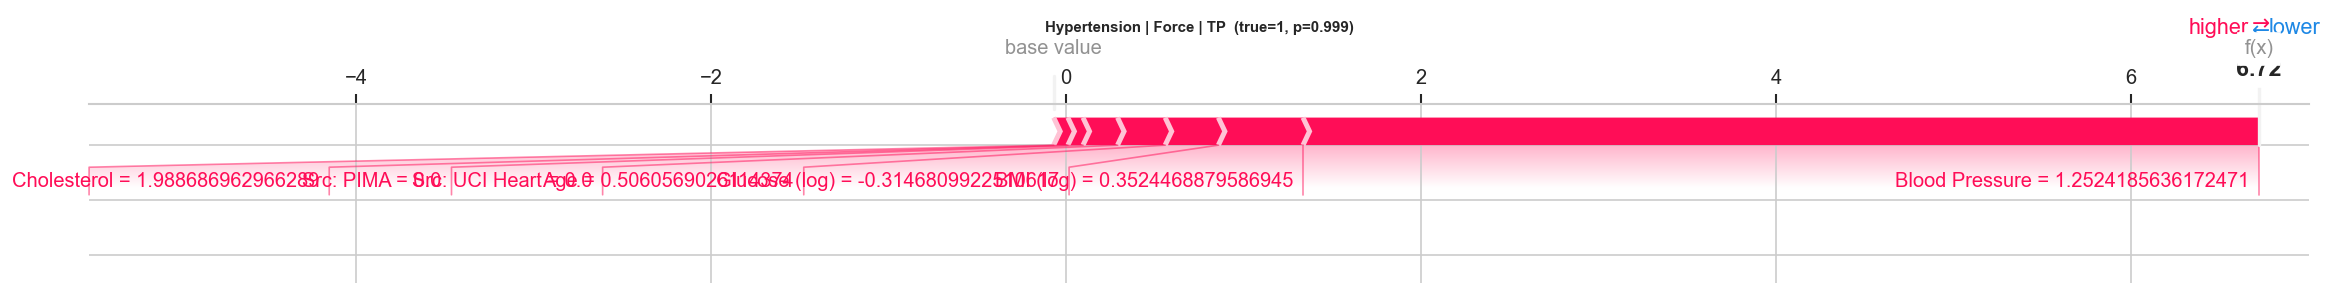

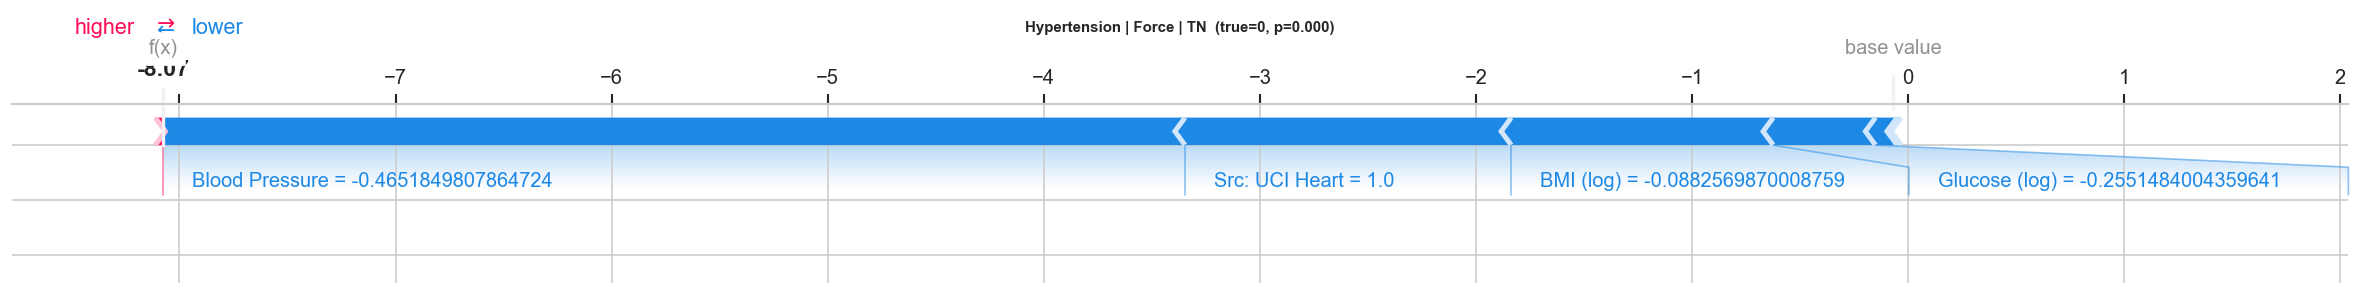

In [11]:
for disease in DISEASES:
    sv     = shap_values_xgb[disease]
    cases  = case_indices[disease]
    y_te   = splits[disease][5].values
    y_prob = xgb_models[disease].predict_proba(splits[disease][2])[:, 1]

    for case_label, idx in cases.items():
        shap.plots.force(
            shap.Explanation(
                values        = sv.values[idx],
                base_values   = float(sv.base_values[idx]),
                data          = sv.data[idx],
                feature_names = FEAT_DISPLAY
            ),
            matplotlib=True, show=False
        )
        plt.title(
            f'{DIS_LABEL[disease]} | Force | {case_label}  '
            f'(true={int(y_te[idx])}, p={y_prob[idx]:.3f})',
            fontsize=9, fontweight='bold', pad=22
        )
        plt.tight_layout()
        plt.savefig(os.path.join(FIGS_DIR,
                    f'27_force_{disease}_{case_label}.png'), bbox_inches='tight')
        plt.show()

## 8. Decision Plots - Cumulative Contribution Paths

Decision plots show how the prediction is built up feature by feature, starting from the expected value and ending at the final prediction. Each line is one test sample; highlighted lines are positive cases.

This reveals where high-risk and low-risk patients diverge in their feature contributions.

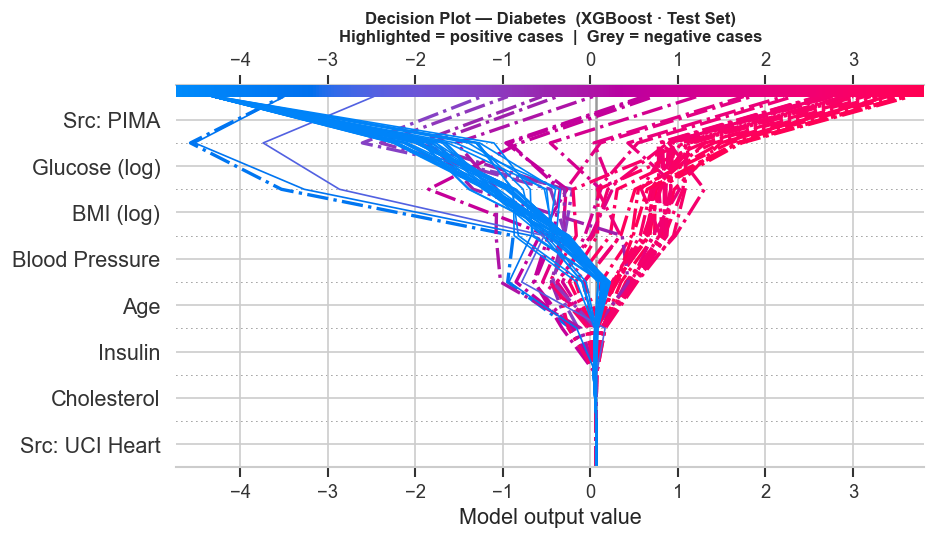

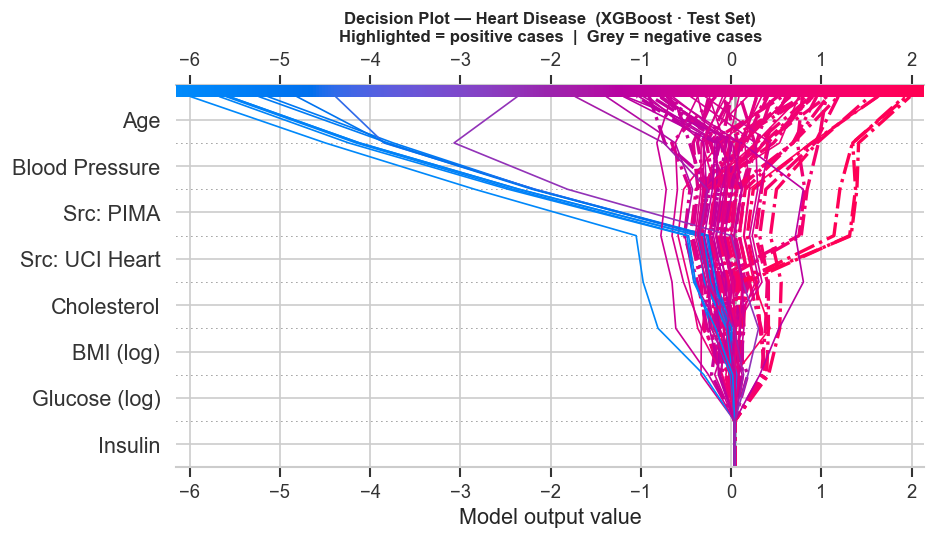

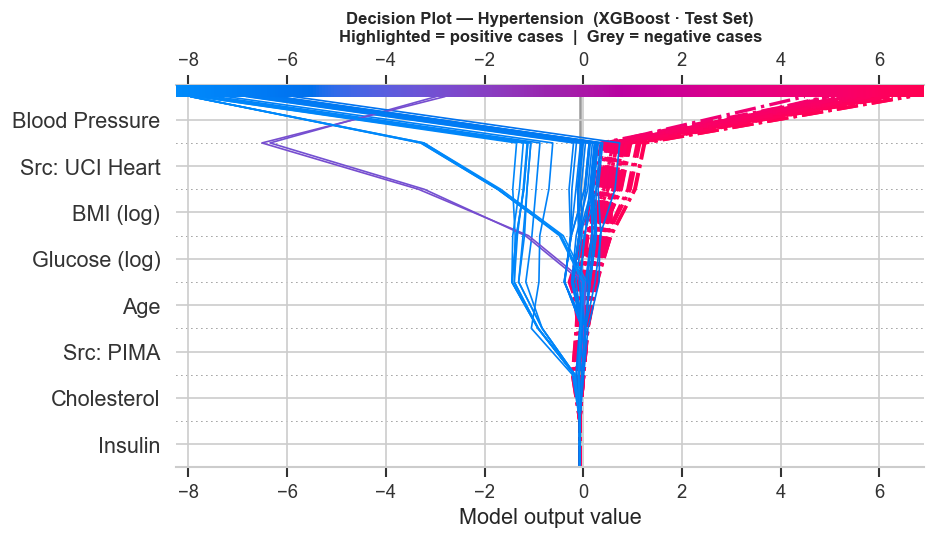

In [12]:
for disease in DISEASES:
    sv   = shap_values_xgb[disease]
    X_te = splits[disease][2]
    y_te = splits[disease][5].values
    base = float(sv.base_values[0])   # constant across samples

    pos_idx = np.where(y_te == 1)[0][:40]
    neg_idx = np.where(y_te == 0)[0][:40]
    sel     = np.concatenate([pos_idx, neg_idx])

    shap.decision_plot(
        base,
        sv.values[sel],
        X_te.iloc[sel],
        feature_names = FEAT_DISPLAY,
        feature_order = 'importance',
        highlight     = np.arange(len(pos_idx)),
        show          = False
    )
    plt.title(
        f'Decision Plot - {DIS_LABEL[disease]}  (XGBoost · Test Set)\n'
        f'Highlighted = positive cases  |  Grey = negative cases',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR, f'28_decision_{disease}.png'), bbox_inches='tight')
    plt.show()

## 9. SHAP Dependence Plots - Feature Interactions

Dependence plots show how a feature's SHAP value changes with its magnitude, while the colour encodes the interaction with a second feature. This exposes non-linear effects and feature interactions that a global importance ranking misses.

Feature pairs are passed as **column indices** to avoid name-lookup issues.

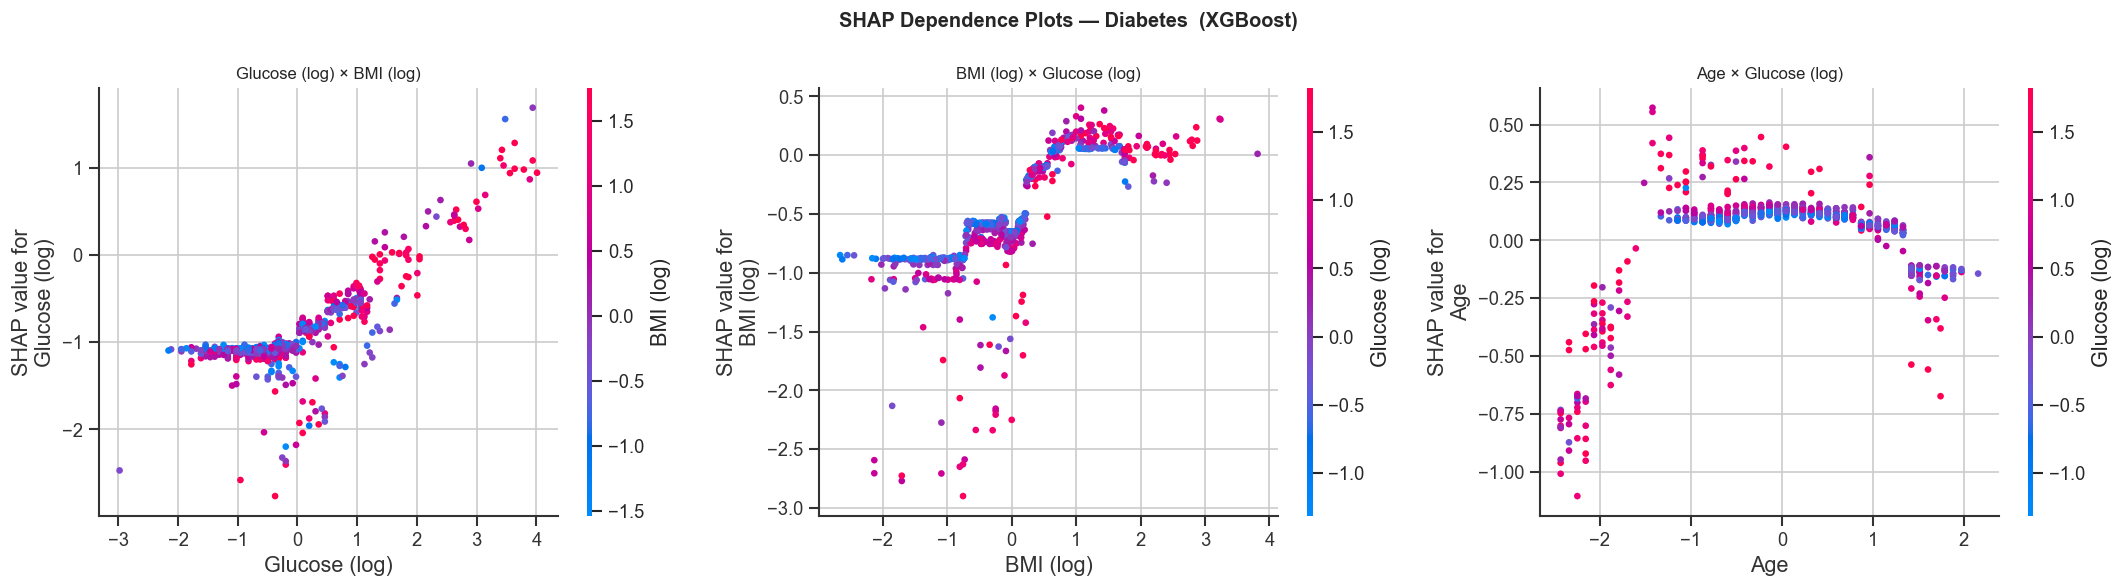

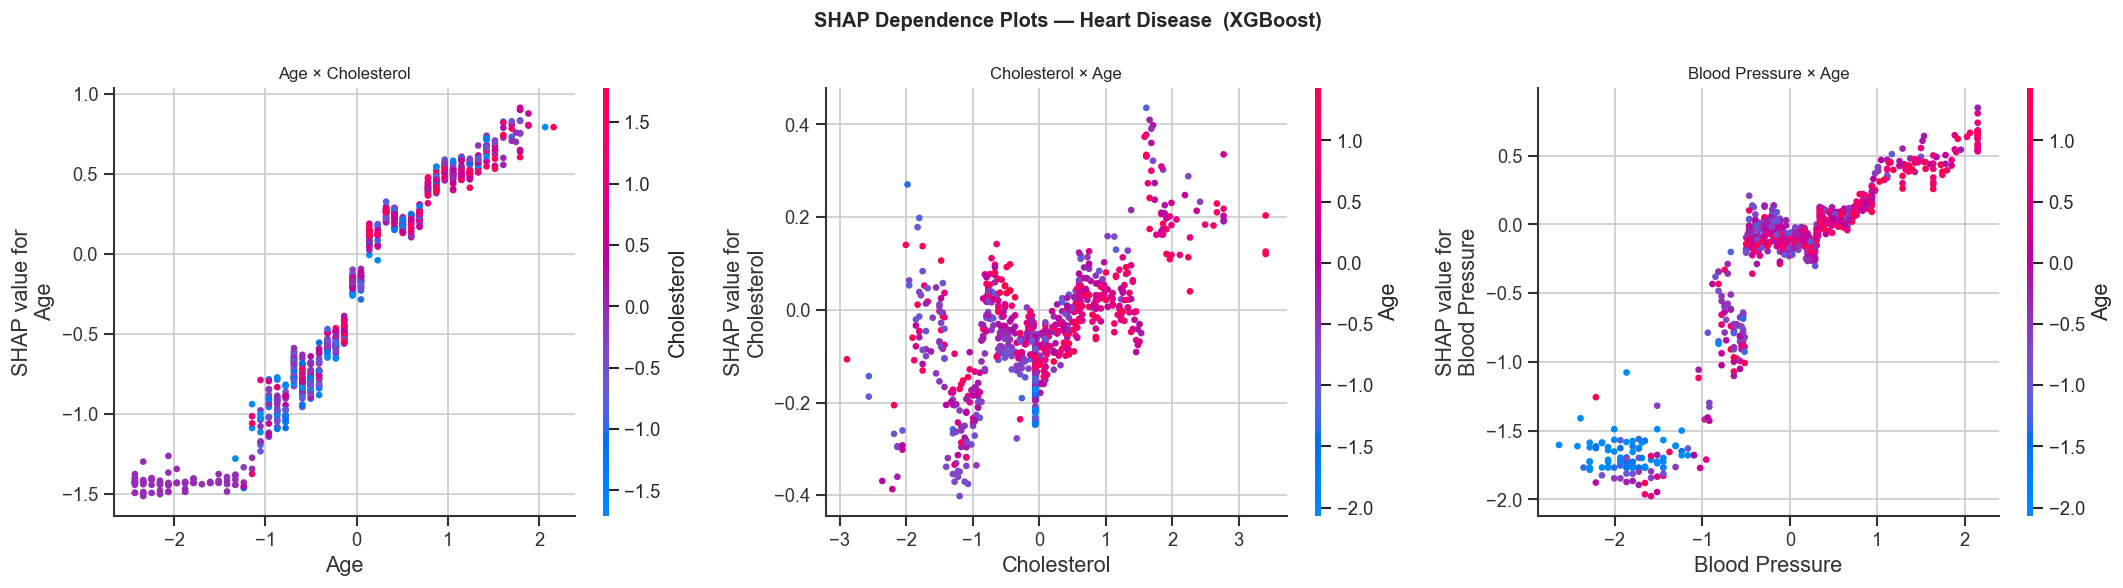

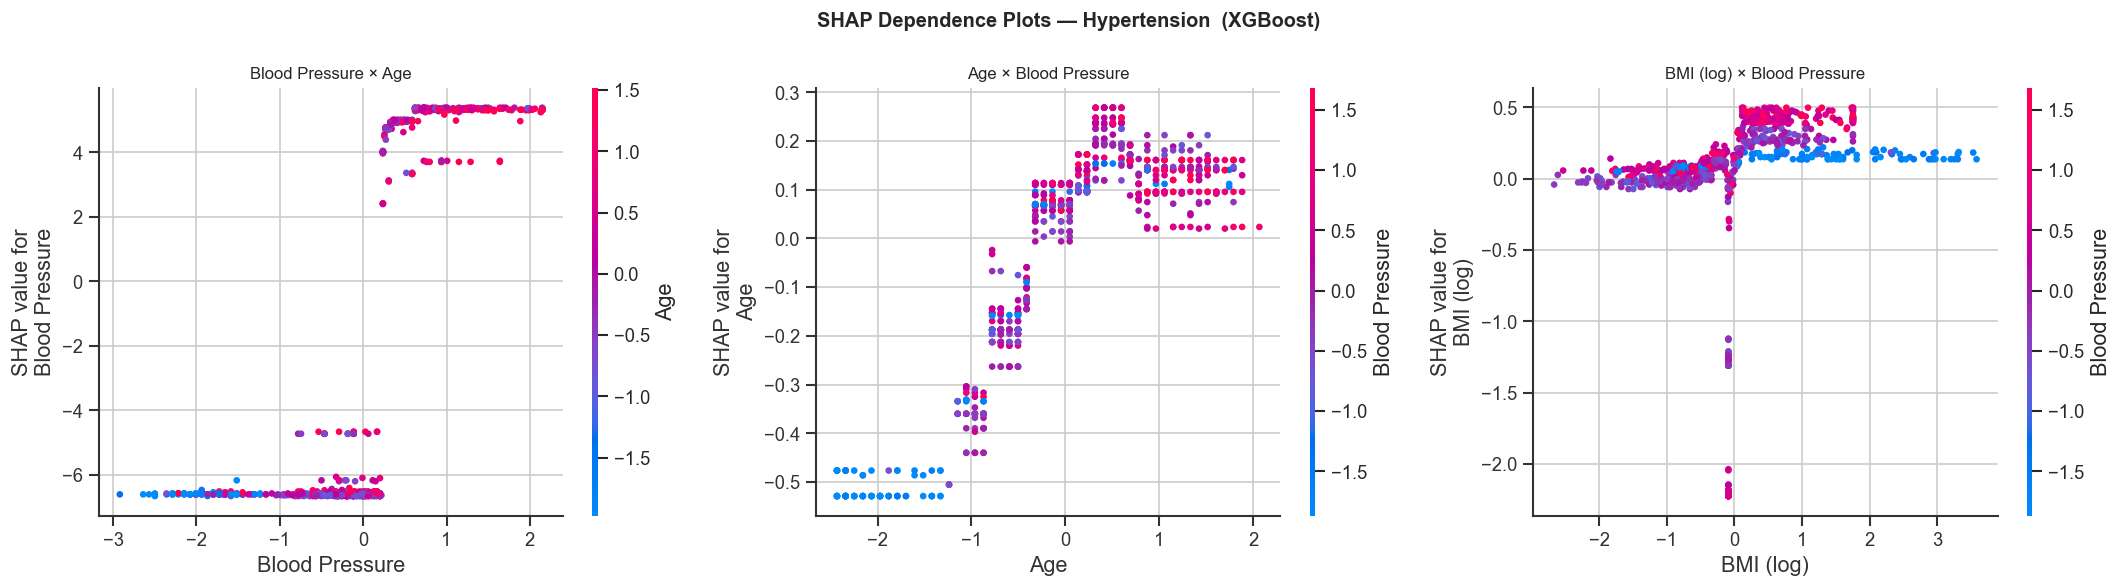

In [13]:
# Interaction pairs as (primary_col_idx, interaction_col_idx)
DEPEND_PAIRS = {
    'diabetes'     : [(FEAT_IDX['glucose'],       FEAT_IDX['bmi']),
                      (FEAT_IDX['bmi'],            FEAT_IDX['glucose']),
                      (FEAT_IDX['age'],            FEAT_IDX['glucose'])],
    'heart_disease': [(FEAT_IDX['age'],            FEAT_IDX['cholesterol']),
                      (FEAT_IDX['cholesterol'],    FEAT_IDX['age']),
                      (FEAT_IDX['blood_pressure'], FEAT_IDX['age'])],
    'hypertension' : [(FEAT_IDX['blood_pressure'], FEAT_IDX['age']),
                      (FEAT_IDX['age'],            FEAT_IDX['blood_pressure']),
                      (FEAT_IDX['bmi'],            FEAT_IDX['blood_pressure'])],
}

for disease, pairs in DEPEND_PAIRS.items():
    n         = len(pairs)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    sv        = shap_values_xgb[disease]
    X_te      = splits[disease][2]

    for ax, (fi, ii) in zip(axes, pairs):
        shap.dependence_plot(
            fi,
            sv.values,
            X_te.values,            # pass numpy array so index lookup works
            feature_names     = FEAT_DISPLAY,
            interaction_index = ii,
            ax                = ax,
            show              = False
        )
        ax.set_title(f'{FEAT_DISPLAY[fi]} × {FEAT_DISPLAY[ii]}', fontsize=10)

    plt.suptitle(f'SHAP Dependence Plots - {DIS_LABEL[disease]}  (XGBoost)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR, f'29_dependence_{disease}.png'), bbox_inches='tight')
    plt.show()

## 10. Cross-Disease Feature Importance Comparison

How does the same feature's importance vary across the three disease prediction tasks? This reveals which clinical measurements are universally important versus disease-specific.

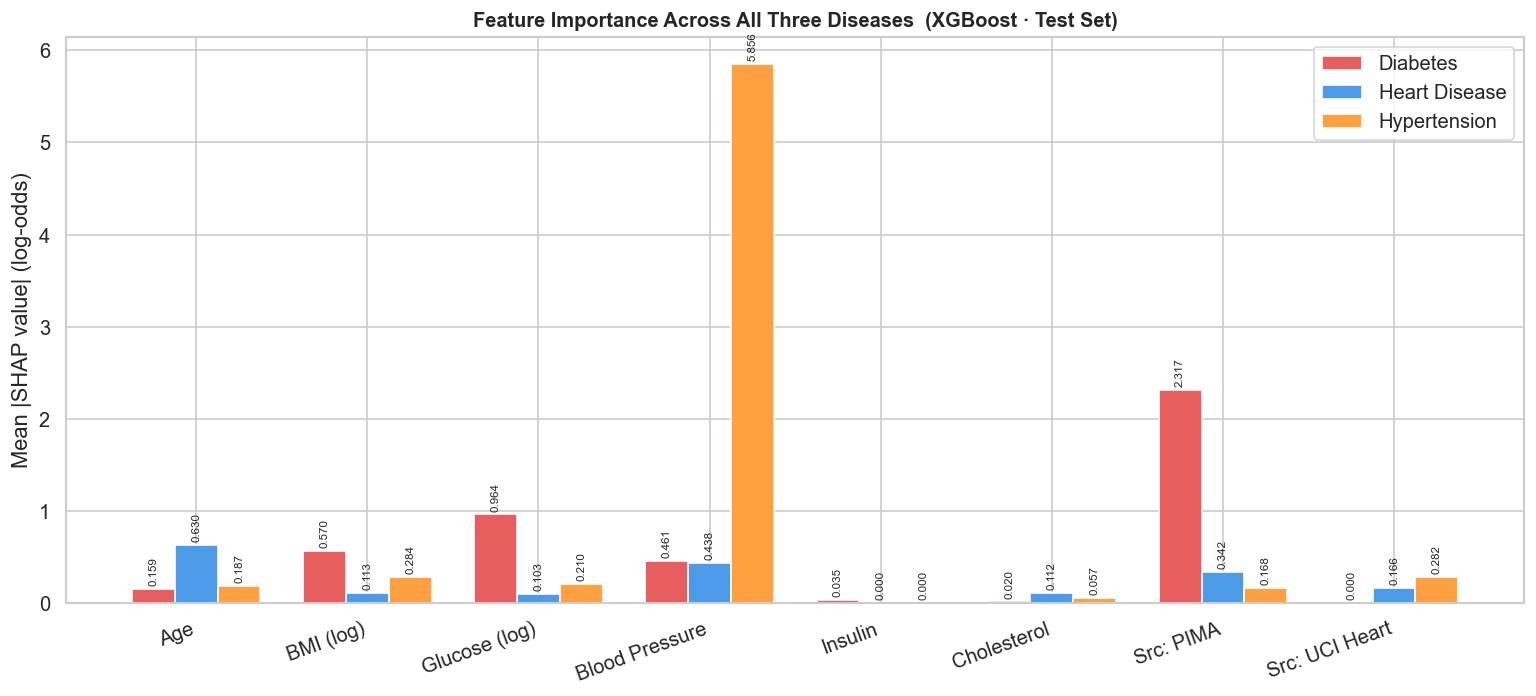


Cross-Disease SHAP Importance:
                Diabetes  Heart Disease  Hypertension
Age               0.1589         0.6299        0.1867
BMI (log)         0.5697         0.1126        0.2838
Glucose (log)     0.9640         0.1033        0.2096
Blood Pressure    0.4609         0.4380        5.8561
Insulin           0.0351         0.0000        0.0000
Cholesterol       0.0197         0.1118        0.0571
Src: PIMA         2.3170         0.3416        0.1682
Src: UCI Heart    0.0000         0.1658        0.2817


In [14]:
shap_importance = {
    disease: np.abs(shap_values_xgb[disease].values).mean(axis=0)
    for disease in DISEASES
}

df_cross = pd.DataFrame(shap_importance, index=FEAT_DISPLAY).rename(columns=DIS_LABEL)

fig, ax = plt.subplots(figsize=(13, 6))
x      = np.arange(len(FEAT_DISPLAY))
w      = 0.25
colors = list(DIS_COLORS.values())

for i, (disease, label) in enumerate(DIS_LABEL.items()):
    offset = (i - 1) * w
    bars   = ax.bar(x + offset, df_cross[label], w,
                    label=label, color=colors[i], edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(FEAT_DISPLAY, rotation=20, ha='right')
ax.set_ylabel('Mean |SHAP value| (log-odds)')
ax.set_title('Feature Importance Across All Three Diseases  (XGBoost · Test Set)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '30_shap_cross_disease.png'))
plt.show()

print('\nCross-Disease SHAP Importance:')
print(df_cross.round(4).to_string())

## 11. Patient Prediction Interface

Accepts raw clinical values and returns:
1. Risk probabilities from all three XGBoost models
2. A SHAP waterfall explanation for each disease

**Preprocessing pipeline** (matches notebook 04):
1. `log1p` applied to `bmi` and `glucose` (skewness > 0.75 threshold)
2. `StandardScaler` applied to all six continuous features
3. Source flags: `source_pima=0`, `source_uci_heart=0` (general / new patient)

In [15]:
def preprocess_patient(patient_dict):
    df = pd.DataFrame([patient_dict])
    df = df[['age', 'bmi', 'glucose', 'blood_pressure', 'insulin', 'cholesterol']]
    for col in LOG_FEATS:
        df[col] = np.log1p(df[col])
    df[SCALE_FEATS] = std_scaler.transform(df[SCALE_FEATS])
    df['source_pima']      = 0
    df['source_uci_heart'] = 0
    return df[FEATURE_NAMES]


def predict_with_explanation(patient_dict, diseases=None):
    if diseases is None:
        diseases = DISEASES
    X_pat   = preprocess_patient(patient_dict)
    results = {}

    print('Patient:')
    for k, v in patient_dict.items():
        print(f'  {k:20s}: {v}')
    print()

    for dis in diseases:
        clf  = xgb_models[dis]
        prob = clf.predict_proba(X_pat)[0, 1]
        pred = int(clf.predict(X_pat)[0])
        results[dis] = {'probability': round(prob, 4), 'prediction': pred}

        sv_exp  = xgb_shap(clf, X_pat, feat_names=FEAT_DISPLAY)
        sv_single = shap.Explanation(
            values        = sv_exp.values[0],
            base_values   = float(sv_exp.base_values[0]),
            data          = sv_exp.data[0],
            feature_names = FEAT_DISPLAY
        )
        risk = 'HIGH RISK' if prob > 0.5 else 'LOW RISK'
        print(f'{DIS_LABEL[dis]:15s}: p={prob:.3f}  [{risk}]')

        shap.plots.waterfall(sv_single, show=False, max_display=8)
        plt.title(
            f'{DIS_LABEL[dis]} - Explanation  (p={prob:.3f}  {risk})',
            fontsize=10, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

    return results


print('Patient prediction interface ready.')

Patient prediction interface ready.


DEMO 1 - High-Risk Patient
Patient:
  age                 : 58
  bmi                 : 34.5
  glucose             : 165.0
  blood_pressure      : 95.0
  insulin             : 180.0
  cholesterol         : 265.0

Diabetes       : p=0.073  [LOW RISK]


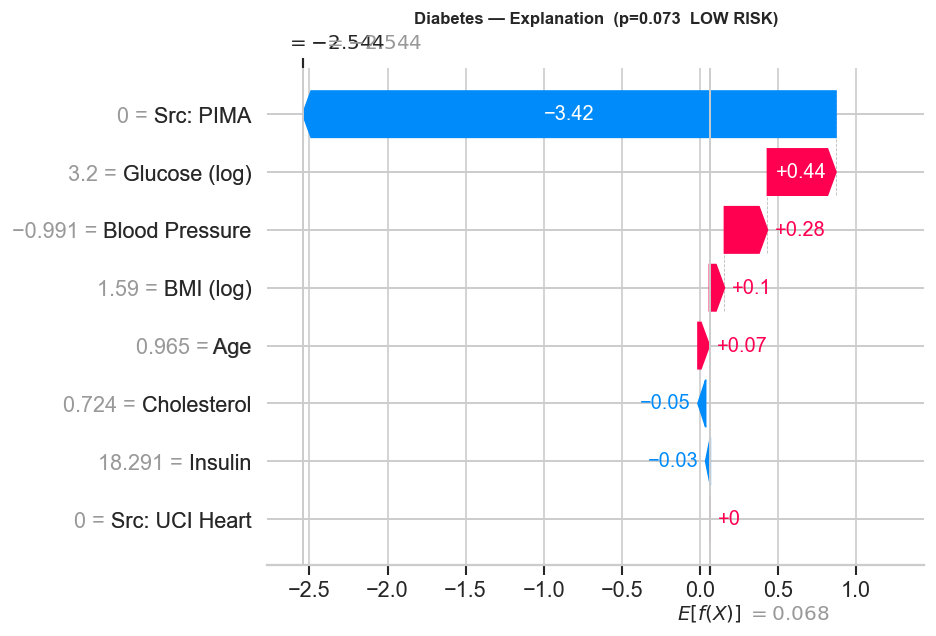

Heart Disease  : p=0.328  [LOW RISK]


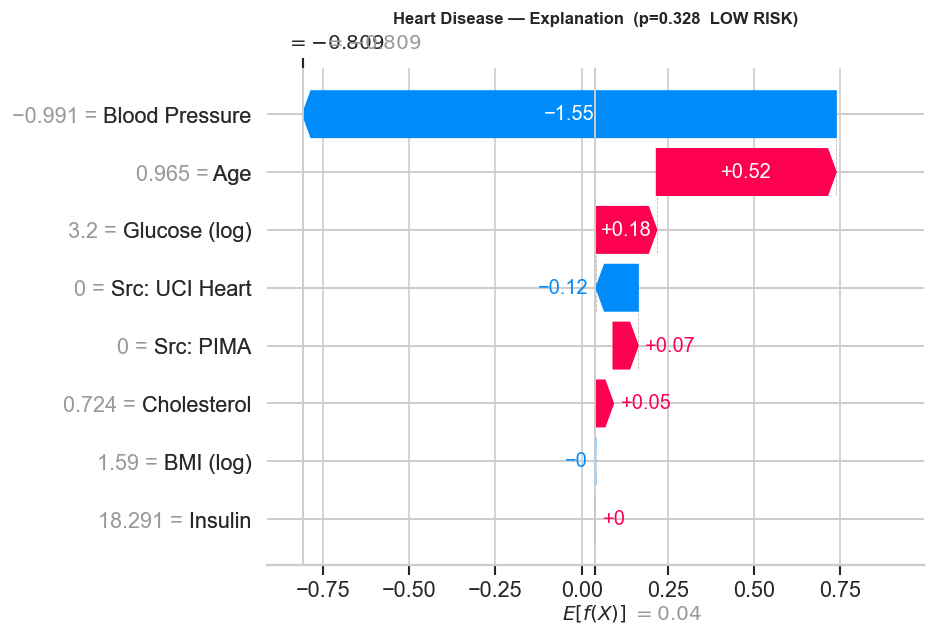

Hypertension   : p=0.003  [LOW RISK]


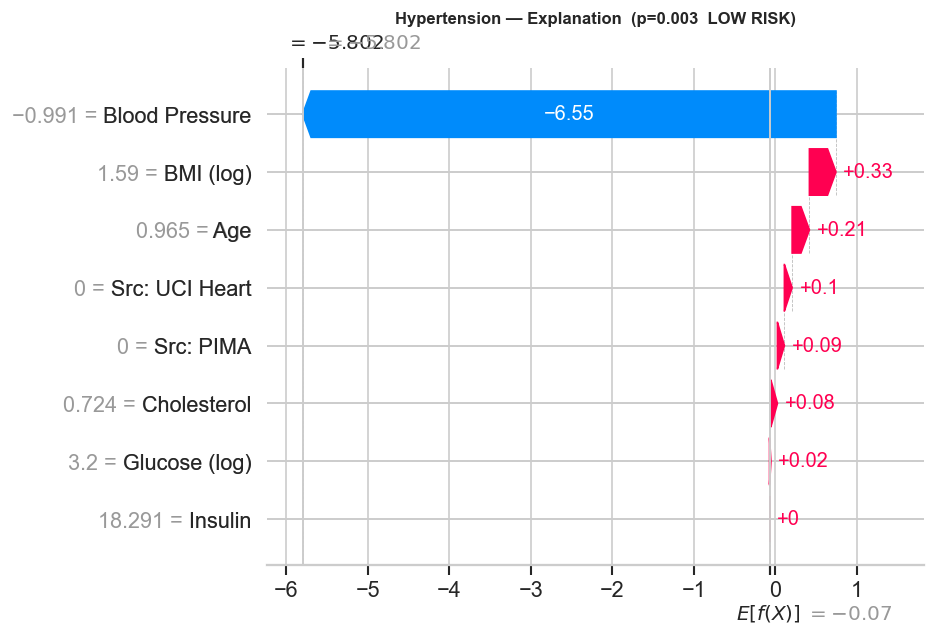

In [16]:
# Demo 1 - High-risk patient
high_risk = {'age': 58, 'bmi': 34.5, 'glucose': 165.0,
             'blood_pressure': 95.0, 'insulin': 180.0, 'cholesterol': 265.0}
print('=' * 60)
print('DEMO 1 - High-Risk Patient')
print('=' * 60)
r1 = predict_with_explanation(high_risk)

DEMO 2 - Low-Risk Patient
Patient:
  age                 : 28
  bmi                 : 22.0
  glucose             : 82.0
  blood_pressure      : 70.0
  insulin             : 90.0
  cholesterol         : 180.0

Diabetes       : p=0.014  [LOW RISK]


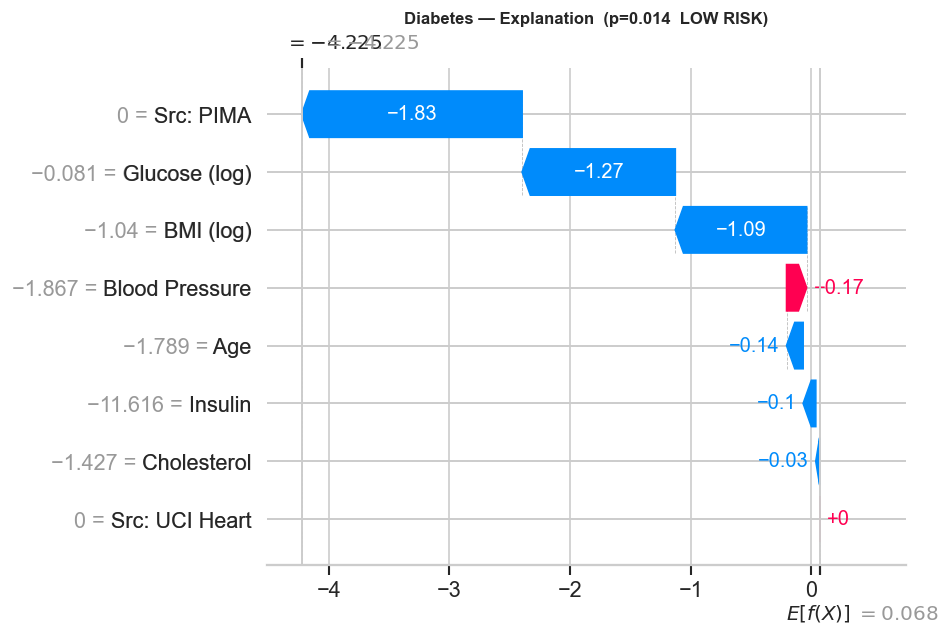

Heart Disease  : p=0.032  [LOW RISK]


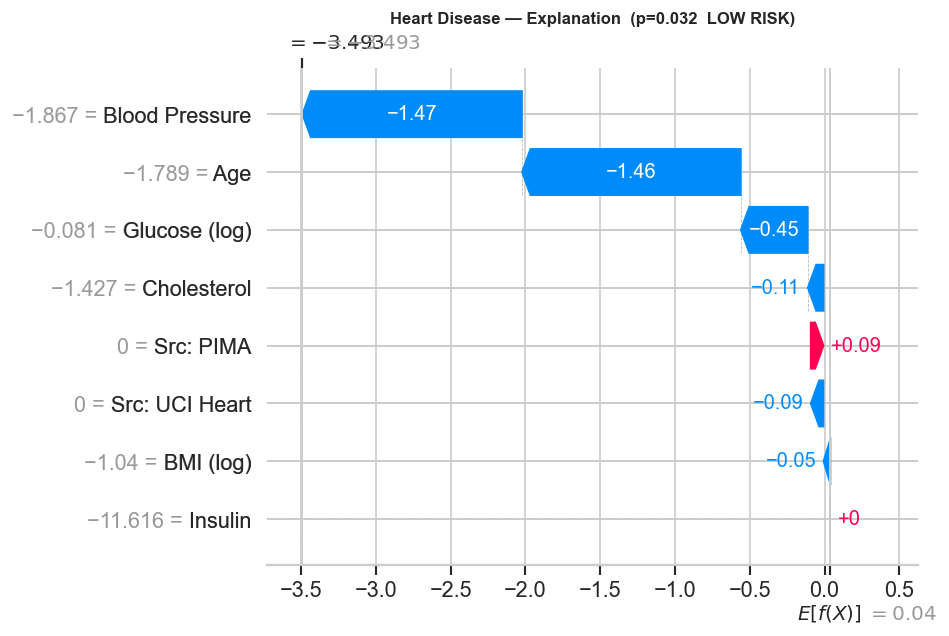

Hypertension   : p=0.001  [LOW RISK]


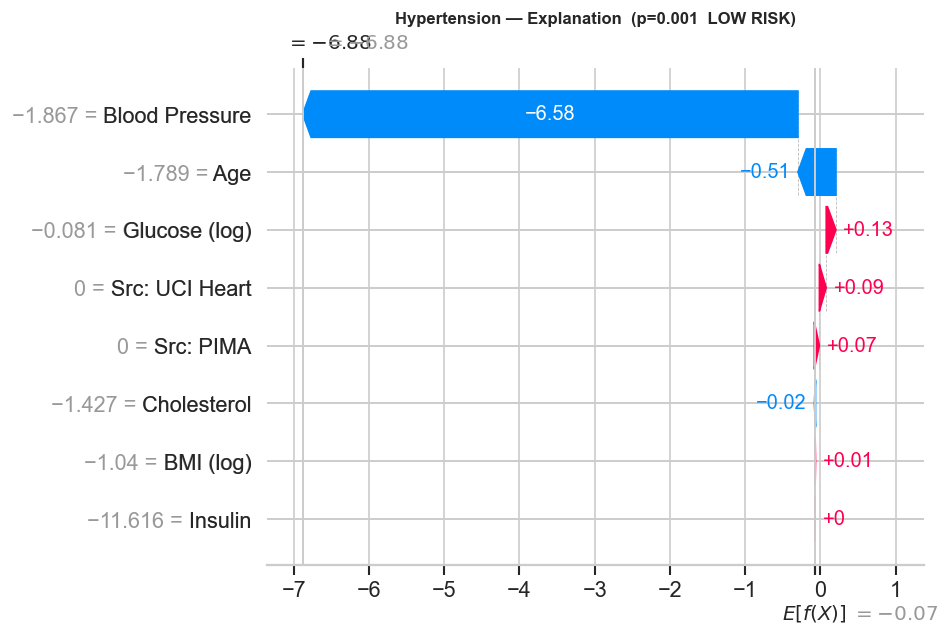

In [17]:
# Demo 2 - Low-risk patient
low_risk = {'age': 28, 'bmi': 22.0, 'glucose': 82.0,
            'blood_pressure': 70.0, 'insulin': 90.0, 'cholesterol': 180.0}
print('=' * 60)
print('DEMO 2 - Low-Risk Patient')
print('=' * 60)
r2 = predict_with_explanation(low_risk)

DEMO 3 - Borderline Patient
Patient:
  age                 : 45
  bmi                 : 27.5
  glucose             : 108.0
  blood_pressure      : 82.0
  insulin             : 125.0
  cholesterol         : 220.0

Diabetes       : p=0.061  [LOW RISK]


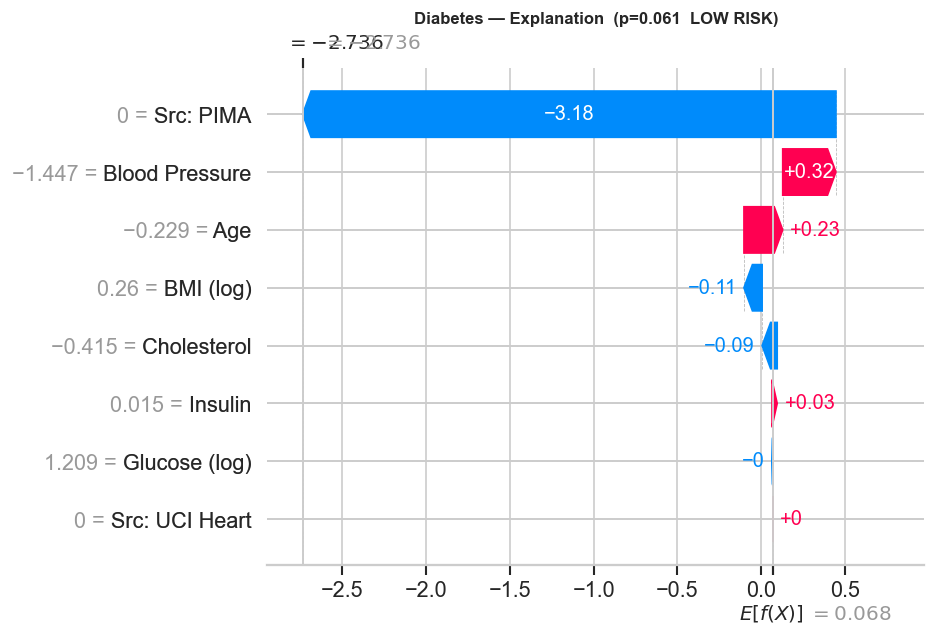

Heart Disease  : p=0.105  [LOW RISK]


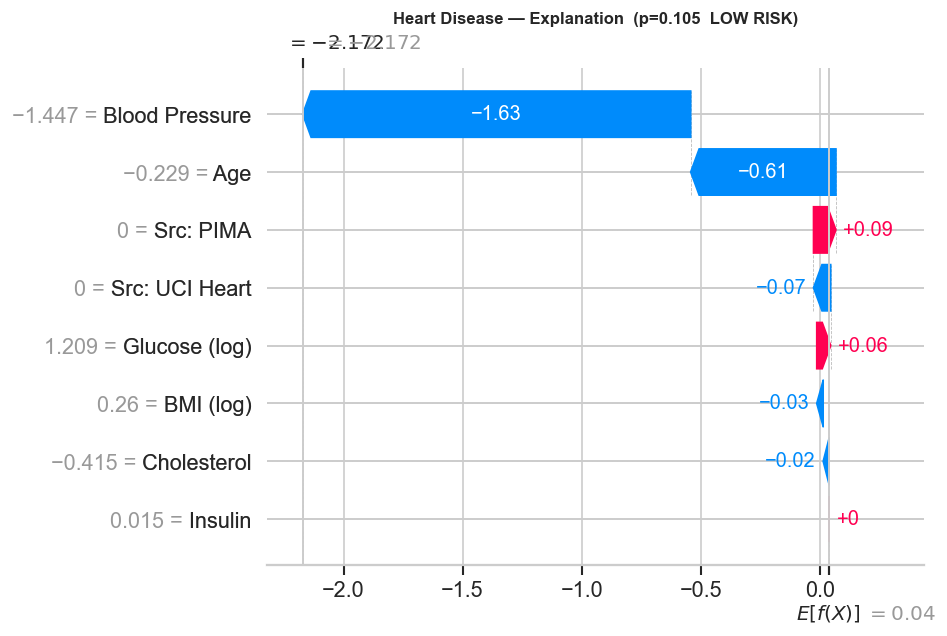

Hypertension   : p=0.002  [LOW RISK]


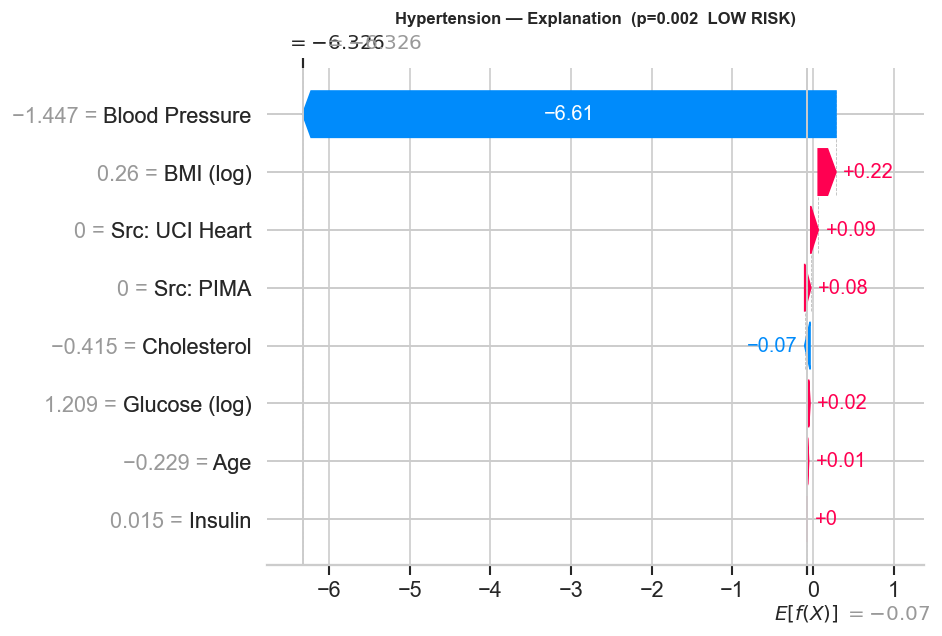

In [18]:
# Demo 3 - Borderline patient
borderline = {'age': 45, 'bmi': 27.5, 'glucose': 108.0,
              'blood_pressure': 82.0, 'insulin': 125.0, 'cholesterol': 220.0}
print('=' * 60)
print('DEMO 3 - Borderline Patient')
print('=' * 60)
r3 = predict_with_explanation(borderline)

## 12. Per-Model SHAP Comparison - XGBoost vs Random Forest

Both models support exact Shapley values via tree traversal. Comparing their feature importance rankings shows whether the two ensemble methods agree on which clinical measurements matter most. High agreement strengthens confidence in those features.

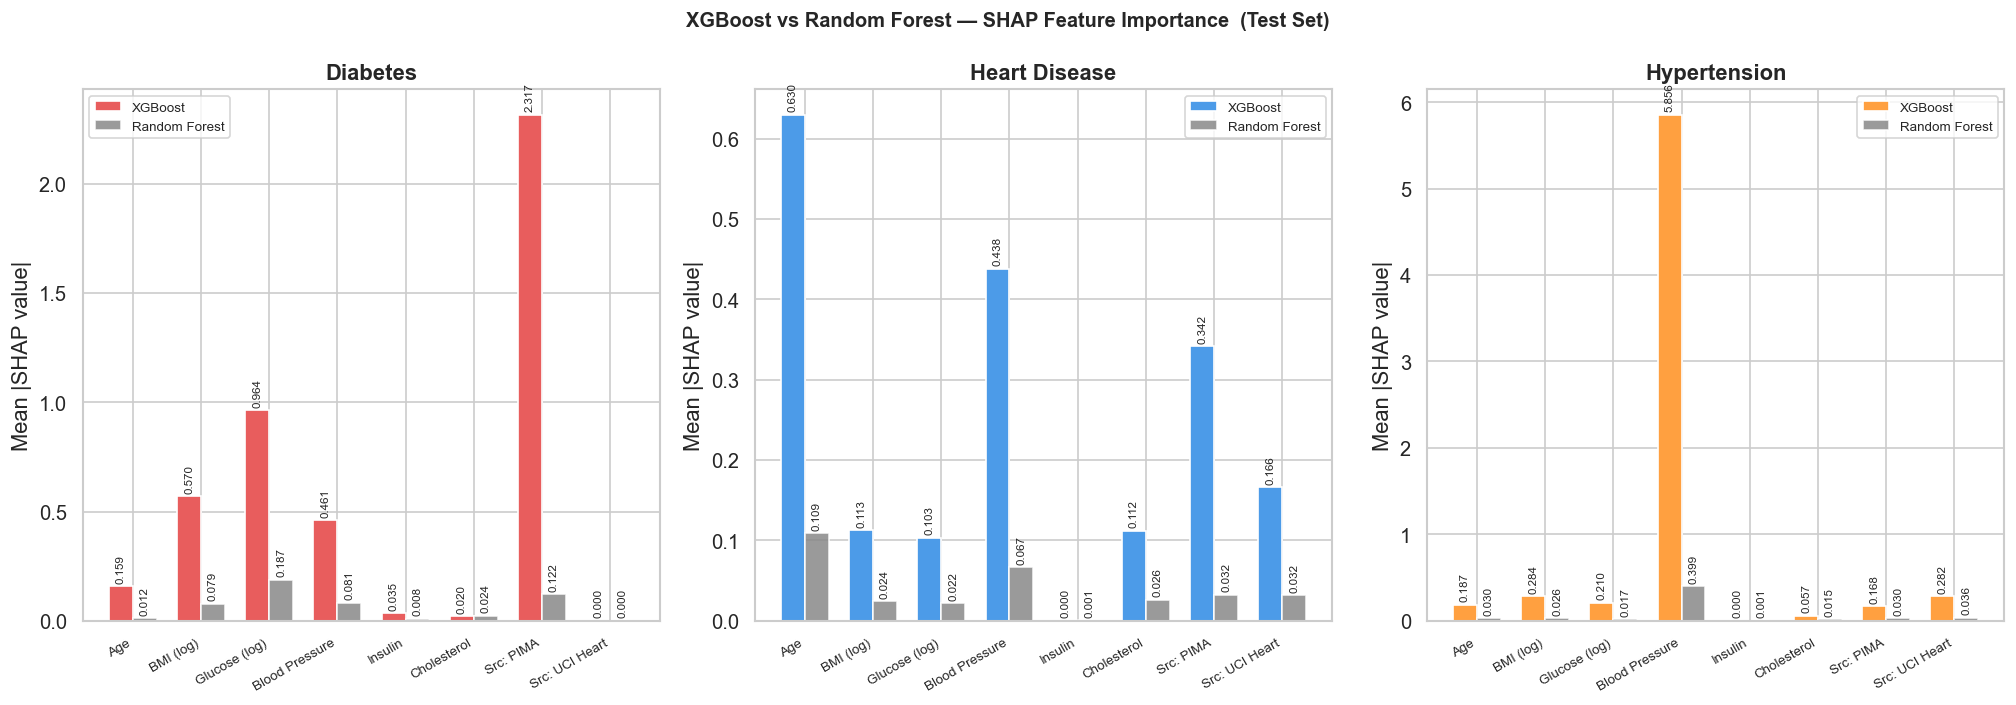


Spearman rank correlation - XGB vs RF SHAP importance:
  Diabetes       : r=0.881  p=0.0039  (strong agreement)
  Heart Disease  : r=0.976  p=0.0000  (strong agreement)
  Hypertension   : r=0.714  p=0.0465  (moderate agreement)


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for ax, disease in zip(axes, DISEASES):
    xgb_imp = np.abs(shap_values_xgb[disease].values).mean(axis=0)
    rf_imp  = np.abs(shap_values_rf[disease].values).mean(axis=0)

    x  = np.arange(len(FEAT_DISPLAY))
    w  = 0.35
    b1 = ax.bar(x - w/2, xgb_imp, w, label='XGBoost',
                color=DIS_COLORS[disease], edgecolor='white')
    b2 = ax.bar(x + w/2, rf_imp,  w, label='Random Forest',
                color='#888888', edgecolor='white', alpha=0.85)
    ax.bar_label(b1, fmt='%.3f', padding=2, fontsize=7, rotation=90)
    ax.bar_label(b2, fmt='%.3f', padding=2, fontsize=7, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(FEAT_DISPLAY, rotation=30, ha='right', fontsize=8)
    ax.set_title(DIS_LABEL[disease], fontweight='bold')
    ax.set_ylabel('Mean |SHAP value|')
    ax.legend(fontsize=8)

plt.suptitle('XGBoost vs Random Forest - SHAP Feature Importance  (Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '31_shap_model_comparison.png'))
plt.show()

print('\nSpearman rank correlation - XGB vs RF SHAP importance:')
for disease in DISEASES:
    xgb_imp = np.abs(shap_values_xgb[disease].values).mean(axis=0)
    rf_imp  = np.abs(shap_values_rf[disease].values).mean(axis=0)
    r, p    = spearmanr(xgb_imp, rf_imp)
    agree   = 'strong' if r > 0.8 else ('moderate' if r > 0.5 else 'weak')
    print(f'  {DIS_LABEL[disease]:15s}: r={r:.3f}  p={p:.4f}  ({agree} agreement)')

## 13. XAI Insights Summary

In [20]:
print('Top Features by Mean |SHAP| (XGBoost · Test Set)')
print('=' * 72)
print(f'{"Disease":20s}  {"Rank 1":20s}  {"Rank 2":20s}  {"Rank 3":20s}')
print('-' * 72)

for disease in DISEASES:
    sv   = shap_values_xgb[disease]
    imp  = np.abs(sv.values).mean(axis=0)
    top3 = np.argsort(imp)[::-1][:3]
    print(f'{DIS_LABEL[disease]:20s}  ' +
          '  '.join(f'{FEAT_DISPLAY[i]:20s}' for i in top3))

print()
print('Direction of Top Feature (at above-median values)')
print('-' * 62)
for disease in DISEASES:
    sv   = shap_values_xgb[disease]
    X_te = splits[disease][2]
    imp  = np.abs(sv.values).mean(axis=0)
    top1 = int(np.argmax(imp))
    feat_vals    = X_te.iloc[:, top1].values
    high_mask    = feat_vals > np.median(feat_vals)
    mean_shap_hi = sv.values[high_mask, top1].mean()
    direction    = 'INCREASES risk' if mean_shap_hi > 0 else 'DECREASES risk'
    print(f'  {DIS_LABEL[disease]:15s}: High {FEAT_DISPLAY[top1]:18s} → '
          f'{direction}  (mean SHAP={mean_shap_hi:+.3f})')

Top Features by Mean |SHAP| (XGBoost · Test Set)
Disease               Rank 1                Rank 2                Rank 3              
------------------------------------------------------------------------
Diabetes              Src: PIMA             Glucose (log)         BMI (log)           
Heart Disease         Age                   Blood Pressure        Src: PIMA           
Hypertension          Blood Pressure        BMI (log)             Src: UCI Heart      

Direction of Top Feature (at above-median values)
--------------------------------------------------------------
  Diabetes       : High Src: PIMA          → INCREASES risk  (mean SHAP=+1.574)
  Heart Disease  : High Age                → INCREASES risk  (mean SHAP=+0.357)
  Hypertension   : High Blood Pressure     → INCREASES risk  (mean SHAP=+3.095)


In [21]:
print('Saved figures:')
saved = [
    '24_shap_bar_importance.png          global mean |SHAP| bar chart (3 diseases)',
    '25_shap_beeswarm_{disease}.png      beeswarm per disease (3 files)',
    '26_waterfall_{disease}_{case}.png   waterfall per disease x case (<=12 files)',
    '27_force_{disease}_{case}.png       force plot per disease x case (<=12 files)',
    '28_decision_{disease}.png           multi-sample decision plots (3 files)',
    '29_dependence_{disease}.png         SHAP dependence / interaction (3 files)',
    '30_shap_cross_disease.png           cross-disease feature importance',
    '31_shap_model_comparison.png        XGBoost vs RF SHAP comparison',
]
for f in saved:
    print(' ', f)
print()
print('Phase 5 - XAI Dashboard complete.')

Saved figures:
  24_shap_bar_importance.png          global mean |SHAP| bar chart (3 diseases)
  25_shap_beeswarm_{disease}.png      beeswarm per disease (3 files)
  26_waterfall_{disease}_{case}.png   waterfall per disease x case (<=12 files)
  27_force_{disease}_{case}.png       force plot per disease x case (<=12 files)
  28_decision_{disease}.png           multi-sample decision plots (3 files)
  29_dependence_{disease}.png         SHAP dependence / interaction (3 files)
  30_shap_cross_disease.png           cross-disease feature importance
  31_shap_model_comparison.png        XGBoost vs RF SHAP comparison

Phase 5 - XAI Dashboard complete.


## Phase 5 Summary

| Item | Detail |
|---|---|
| **Explainer (XGBoost)** | Native `pred_contribs=True` - exact Shapley, XGBoost 3.x compatible |
| **Explainer (RF)** | `shap.TreeExplainer` - exact Shapley (sklearn RF) |
| **Global plots** | Bar (mean \|SHAP\|) + Beeswarm per disease |
| **Local plots** | Waterfall + Force for TP, FN, FP, TN cases per disease |
| **Multi-sample** | Decision plots for up to 80 test samples per disease |
| **Interactions** | Dependence plots for top feature pairs per disease |
| **Patient interface** | `predict_with_explanation()` - real-time prediction + SHAP waterfall |
| **Model agreement** | Spearman ρ between XGBoost and RF SHAP rankings |
| **Saved figures** | 8 plot types → `Scripts/reports/figures/` |